# The Art of Analyzing Big Data – The Data Scientist’s Toolbox


# Network Analysis, Visualization, Graph Embeddings, and Link Prediction

# Part A — Movie / Social Network Analysis

## Task A1.1 — Degree Distribution

In [ ]:
# importing necessary libraries
import json
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from networkx.readwrite import json_graph
from pathlib import Path

In [ ]:
# Define the path to the dataset
DATASET_PATH = Path(
    r"D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\archive (2)\moviedynamics"
)

movie_file = DATASET_PATH / "2010_Harry_Potter_and_the_Deathly_Hallows_Part_1.json"

actors_file = DATASET_PATH / "2010_Harry_Potter_and_the_Deathly_Hallows_Part_1.actors.json"

In [ ]:
# Load the movie data
with open(movie_file, "r", encoding="utf-8") as f:
    movie_data = json.load(f)

G = json_graph.node_link_graph(movie_data, edges="links")

print("Graph loaded successfully")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Graph loaded successfully
Number of nodes: 58
Number of edges: 313


In [ ]:
# Display a sample of nodes and edges
print("\nSample Nodes:")
print(list(G.nodes(data=True))[:5])

print("\nSample Edges:")
print(list(G.edges(data=True))[:5])


Sample Nodes:
[('Mary Cattermole', {'first': 6, 'last': 3586, 'role': 'Kate Fleetwood'}), ('Harry Potter', {'first': 7, 'last': 3565, 'role': 'Daniel Radcliffe'}), ('Mr. Ollivander', {'first': 10, 'last': 2512, 'role': 'John Hurt'}), ('Hermione Granger', {'first': 17, 'last': 3512, 'role': 'Emma Watson'}), ('Scabior', {'first': 19, 'last': 753, 'role': 'Nick Moran'})]

Sample Edges:
[('Mary Cattermole', 'Harry Potter', {'first': 7, 'last': 3586, 'weight': 28}), ('Mary Cattermole', 'Hermione Granger', {'first': 17, 'last': 3559, 'weight': 13}), ('Mary Cattermole', 'Scabior', {'first': 19, 'last': 188, 'weight': 5}), ('Mary Cattermole', 'Ron Weasley', {'first': 25, 'last': 3559, 'weight': 11}), ('Mary Cattermole', 'Reg Cattermole', {'first': 31, 'last': 3586, 'weight': 8})]


## Degree Distribution Analysis

The degree of a node represents the number of connections that the node has with other nodes in the network.In this movie interaction network, a high-degree character is a character that interacts with many other characters throughout the movie.Analyzing the degree distribution helps identify:Main characters, Supporting characters,Network hubs and  Whether the network is centralized around a few important characters.

In [ ]:
# Calculate the degree of each node
degrees = dict(G.degree())

degree_df = pd.DataFrame({
    "Character": list(degrees.keys()),
    "Degree": list(degrees.values())
})

degree_df = degree_df.sort_values(
    by="Degree",
    ascending=False
)

degree_df.head(10)

,Character,Degree
1,Harry Potter,55
3,Hermione Granger,48
5,Ron Weasley,41
27,Professor Albus Dumbledore,27
21,Lord Voldemort,25
26,Dobby,20
0,Mary Cattermole,19
4,Scabior,16
20,Luna Lovegood,15
32,Fred Weasley,15


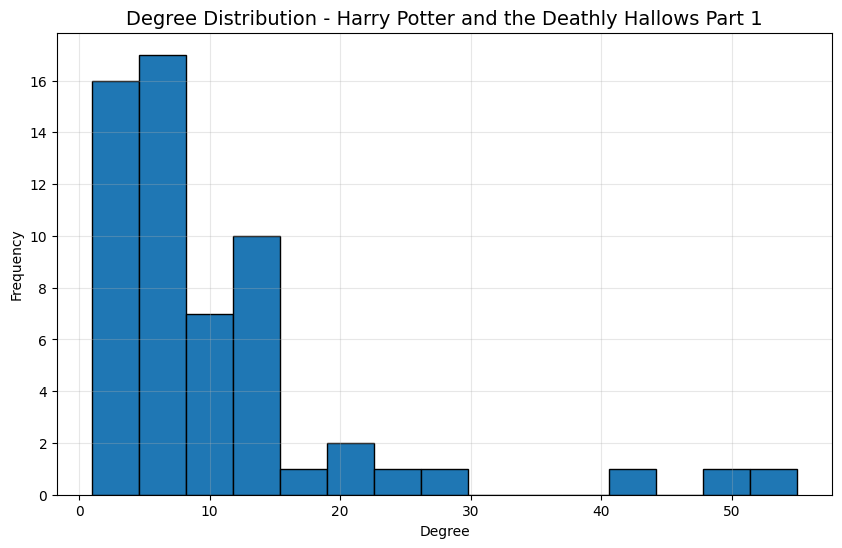

In [ ]:
# Plotting the degree distribution
plt.figure(figsize=(10, 6))

plt.hist(
    degree_df["Degree"],
    bins=15,
    edgecolor="black"
)

plt.title(
    "Degree Distribution - Harry Potter and the Deathly Hallows Part 1",
    fontsize=14
)

plt.xlabel("Degree")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Display the top 10 characters by degree
top_degree_characters = degree_df.head(10)

top_degree_characters

,Character,Degree
1,Harry Potter,55
3,Hermione Granger,48
5,Ron Weasley,41
27,Professor Albus Dumbledore,27
21,Lord Voldemort,25
26,Dobby,20
0,Mary Cattermole,19
4,Scabior,16
20,Luna Lovegood,15
32,Fred Weasley,15


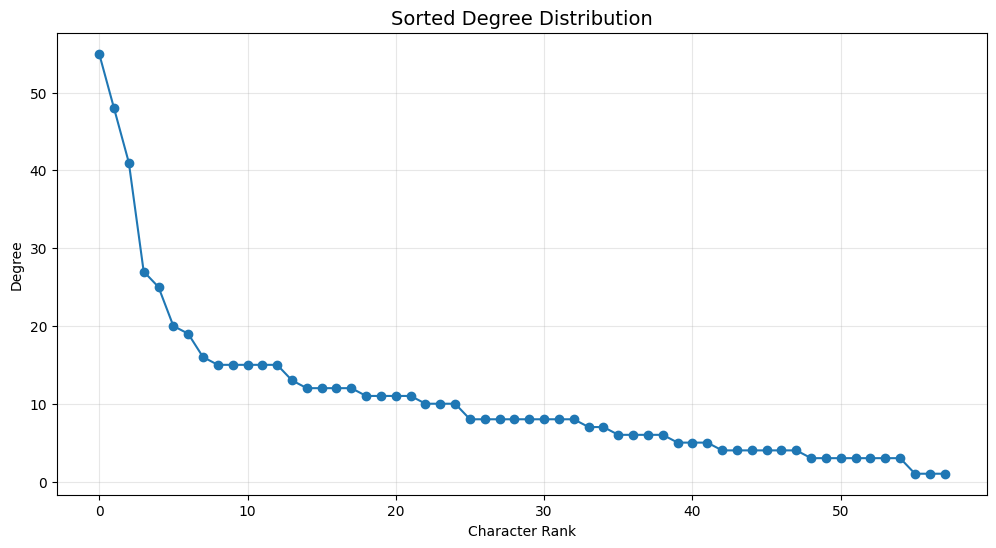

In [ ]:
# Plotting the sorted degree distribution
plt.figure(figsize=(12, 6))

sorted_degrees = sorted(
    degree_df["Degree"],
    reverse=True
)

plt.plot(
    sorted_degrees,
    marker="o"
)

plt.title(
    "Sorted Degree Distribution",
    fontsize=14
)

plt.xlabel("Character Rank")
plt.ylabel("Degree")

plt.grid(alpha=0.3)

plt.show()

## Discussion of the Degree Distribution

The degree distribution shows that the network is highly uneven.

A small number of characters have very high degree values, while most characters have relatively few connections. This indicates that the story is centered around several major characters.

The highest-degree characters are Harry Potter, Hermione Granger,Ron Weasley.These characters interact with many others throughout the movie and therefore act as hubs in the network.

The long-tail structure of the distribution suggests that the movie contains many minor or supporting characters with limited interactions.

## How I solved this task

I selected the Harry Potter and the Deathly Hallows: Part 1 (2010) network from the Movie Dynamics dataset and loaded it into NetworkX.

Then, I calculated the degree of each character using G.degree(), stored the results in a Pandas DataFrame,visualized the degree distribution with a histogram and a sorted degree plot.

I chose degree analysis because it is a simple and effective way to identify the most connected and important characters in a network.

The results show that the network is centered around a few key characters, particularly Harry Potter, Hermione Granger, and Ron Weasley, while most characters have relatively few connections.


# A1.2 Graph Embeddings of Movie Networks 

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [20]:
all_movie_files = []

for file in DATASET_PATH.glob("*.json"):
    
    if ".actors." not in file.name:
        all_movie_files.append(file)

print("Number of movie networks:", len(all_movie_files))

all_movie_files[:10]

Number of movie networks: 15538


[WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1920_The_Penalty.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1920_Way_Down_East.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1921_The_Sheik.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1922_Beyond_the_Rocks.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1922_Dr_Mabuse_The_Gambler.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1922_Nathan_der_Weise.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1922_Nosferatu.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1924_Die_Nibelungen_Kriemhild_s_Revenge.json'),
 WindowsPath('D:/Masters Study/

In [22]:
#feature extraction function
def extract_graph_features(graph):
    
    features = {}
    
    features["num_nodes"] = graph.number_of_nodes()
    features["num_edges"] = graph.number_of_edges()
    
    features["density"] = nx.density(graph)
    
    degrees = [d for _, d in graph.degree()]
    
    features["avg_degree"] = np.mean(degrees)
    features["max_degree"] = np.max(degrees)
    
    features["avg_clustering"] = nx.average_clustering(graph)
    
    features["transitivity"] = nx.transitivity(graph)
    
    try:
        features["assortativity"] = nx.degree_assortativity_coefficient(graph)
    except:
        features["assortativity"] = 0
    
    # Largest connected component
    if nx.is_connected(graph):
        largest_cc = graph
    else:
        largest_nodes = max(nx.connected_components(graph), key=len)
        largest_cc = graph.subgraph(largest_nodes)
    
    try:
        features["avg_shortest_path"] = nx.average_shortest_path_length(largest_cc)
    except:
        features["avg_shortest_path"] = 0
    
    try:
        features["diameter"] = nx.diameter(largest_cc)
    except:
        features["diameter"] = 0
    
    return features

In [23]:
#Build embedding dataset
movie_features = []

for movie_path in all_movie_files:
    
    try:
        with open(movie_path, "r", encoding="utf-8") as f:
            movie_json = json.load(f)
        
        graph = json_graph.node_link_graph(
            movie_json,
            edges="links"
        )
        
        features = extract_graph_features(graph)
        
        features["movie"] = movie_path.stem
        
        movie_features.append(features)
    
    except Exception as e:
        print("Error:", movie_path.name, e)

feature_df = pd.DataFrame(movie_features)

feature_df.head()

c:\Users\hp\miniconda3\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


,num_nodes,num_edges,density,avg_degree,max_degree,avg_clustering,transitivity,assortativity,avg_shortest_path,diameter,movie
0,3,2,0.666667,1.333333,2,0.000000,0.000000,-1.000000,1.333333,2,1920_The_Penalty
1,8,17,0.607143,4.250000,7,0.667857,0.681818,-0.479630,1.392857,2,1920_Way_Down_East
2,4,3,0.500000,1.500000,2,0.000000,0.000000,-0.500000,1.666667,3,1921_The_Sheik
3,7,7,0.333333,2.000000,5,0.204762,0.214286,-0.736842,1.809524,3,1922_Beyond_the_Rocks
4,4,4,0.666667,2.000000,3,0.583333,0.600000,-0.714286,1.333333,2,1922_Dr_Mabuse_The_Gambler


In [24]:
#Prepare Feature Matrix
movie_names = feature_df["movie"]

X = feature_df.drop(columns=["movie"])

X = X.fillna(0)

In [25]:
#Normalize features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
#PCA Projection
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "movie": movie_names
})

pca_df.head()

,PCA1,PCA2,movie
0,-3.520172,-2.085837,1920_The_Penalty
1,-1.069200,1.229531,1920_Way_Down_East
2,-2.301779,-2.838772,1921_The_Sheik
3,-1.317090,-2.737433,1922_Beyond_the_Rocks
4,-2.564186,0.576628,1922_Dr_Mabuse_The_Gambler


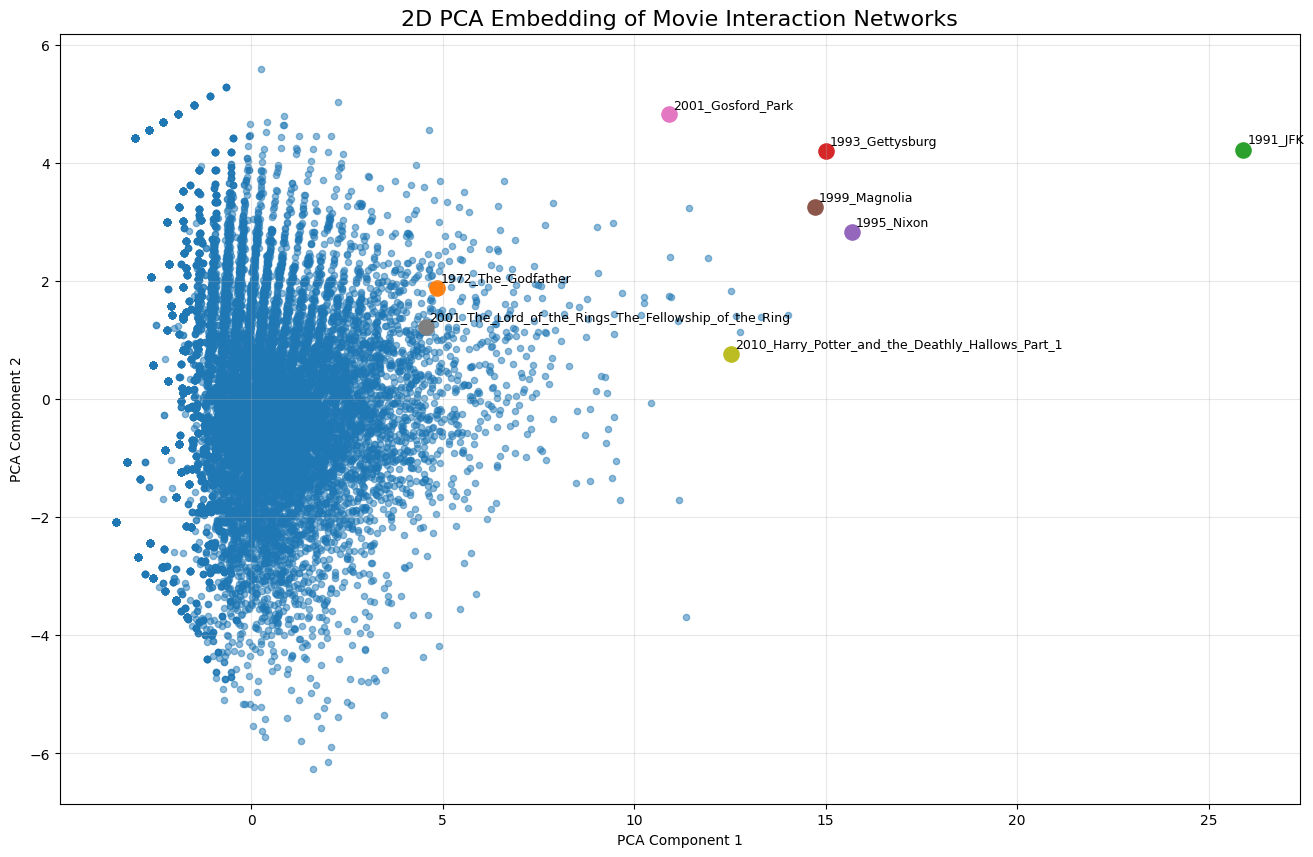

In [28]:
#visualization
plt.figure(figsize=(16, 10))

# Plot all points
plt.scatter(
    pca_df["PCA1"],
    pca_df["PCA2"],
    alpha=0.5,
    s=20
)

# Label only selected movies
interesting_movies = [
    "2010_Harry_Potter_and_the_Deathly_Hallows_Part_1",
    "2001_The_Lord_of_the_Rings_The_Fellowship_of_the_Ring",
    "1972_The_Godfather",
    "1991_JFK",
    "1993_Gettysburg",
    "1995_Nixon",
    "1999_Magnolia",
    "2001_Gosford_Park"
]

subset = pca_df[
    pca_df["movie"].isin(interesting_movies)
]

for _, row in subset.iterrows():
    
    plt.scatter(
        row["PCA1"],
        row["PCA2"],
        s=120
    )
    
    plt.text(
        row["PCA1"] + 0.1,
        row["PCA2"] + 0.1,
        row["movie"],
        fontsize=9
    )

plt.title(
    "2D PCA Embedding of Movie Interaction Networks",
    fontsize=16
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.grid(alpha=0.3)

plt.show()

# similarity analysis

In [30]:
from sklearn.metrics.pairwise import euclidean_distances
#similarity matrix
distance_matrix = euclidean_distances(X_scaled)

distance_df = pd.DataFrame(
    distance_matrix,
    index=movie_names,
    columns=movie_names
)
#find similar movies to Harry Potter
target_movie = "2010_Harry_Potter_and_the_Deathly_Hallows_Part_1"

similar_movies = (
    distance_df[target_movie]
    .drop(target_movie)
    .sort_values()
    .head(10)
)

similar_movies

movie
1994_Wyatt_Earp                                   1.884189
1990_Goodfellas                                   2.064999
1992_The_Player                                   2.137369
2013_The_Wolf_of_Wall_Street                      2.402940
2007_Harry_Potter_and_the_Order_of_the_Phoenix    2.664116
2017_The_Post                                     3.294512
2012_West_of_Memphis                              3.365827
2007_American_Gangster                            3.405432
2005_Miss_Congeniality_2_Armed_and_Fabulous       3.557465
2003_Gods_and_Generals                            3.565091
Name: 2010_Harry_Potter_and_the_Deathly_Hallows_Part_1, dtype: float64

## Similar Movie Networks

Using Euclidean distance in the embedding space, several structurally similar movies were identified.

The closest movie networks to **Harry Potter and the Deathly Hallows: Part 1**

include: Harry Potter and the Order of the Phoenix, Goodfellas, The Player, The Wolf of Wall Street.

These movies likely appear similar because they contain many interacting characters, several important hubs, dense social interactions,and relatively complex narrative structures.

The embedding captures structural similarity rather than movie genre. Therefore, movies from different genres may still appear close together if their interaction networks are organized similarly.

## How I solved this task

For this task, I created graph level embeddings for multiple movie networks from the Movie Dynamics dataset.I used a structural feature embedding approach based on graph statistics. This approach is simpler to interpret and allows direct comparison between network structures.

For each movie network, I extracted several structural properties including Number of nodes,Number of edges, Graph density,Average degree, Maximum degree,Average clustering coefficient, Transitivity, Degree assortativity, Average shortest path length, Diameter.These graph statistics form a numerical feature vector that represents the structure of each movie network.

After generating the feature vectors, I standardized the features and applied PCA to reduce the high dimensional vectors into a 2 dimensional representation.

I then visualized all movie networks in 2D space and used Euclidean distance in the embedding space to identify structurally similar movies.

This approach allows comparison of movie interaction networks according to their structural organization rather than their narrative content or genre.

# Task A2 — Top-12 Character Subgraph

In [31]:
#compute betweenness centrality 
betweenness = nx.betweenness_centrality(
    G,
    weight="weight"
)

betweenness_df = pd.DataFrame({
    "Character": list(betweenness.keys()),
    "Betweenness": list(betweenness.values())
})

betweenness_df = betweenness_df.sort_values(
    by="Betweenness",
    ascending=False
)

betweenness_df.head(12)

,Character,Betweenness
3,Hermione Granger,0.202506
21,Lord Voldemort,0.181078
5,Ron Weasley,0.180900
56,Minister Rufus Scrimgeour,0.075710
0,Mary Cattermole,0.056067
34,Remus Lupin,0.046000
32,Fred Weasley,0.045969
1,Harry Potter,0.045238
8,Dudley Dursley,0.044162
15,Draco Malfoy,0.043745


## Selected Centrality Algorithm

The selected algorithm is **betweenness centrality**.

Betweenness centrality is useful because it identifies nodes that frequently connect different parts of the network.

In a movie interaction network, characters with high betweenness centrality often serve as connectors between multiple groups of characters and therefore play an important narrative role.

In [32]:
#select top 12 characters
top_12_characters = (
    betweenness_df.head(12)["Character"]
    .tolist()
)

top_12_characters

['Hermione Granger',
 'Lord Voldemort',
 'Ron Weasley',
 'Minister Rufus Scrimgeour',
 'Mary Cattermole',
 'Remus Lupin',
 'Fred Weasley',
 'Harry Potter',
 'Dudley Dursley',
 'Draco Malfoy',
 'Professor Albus Dumbledore',
 'Dobby']

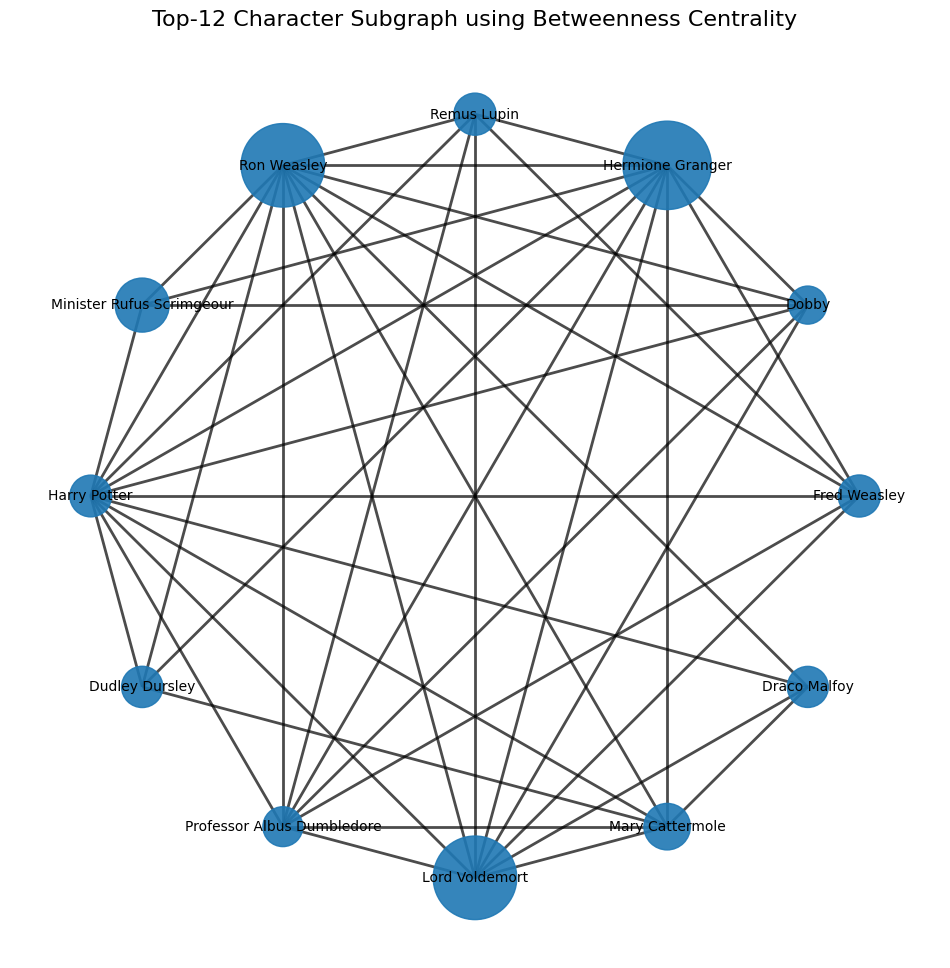

In [35]:
#create subgraph
top_subgraph = G.subgraph(
    top_12_characters
)
#visualization
plt.figure(figsize=(12, 12))

pos = nx.circular_layout(top_subgraph)

node_sizes = []

for node in top_subgraph.nodes():
    node_sizes.append(
        betweenness[node] * 20000
    )

nx.draw_networkx_nodes(
    top_subgraph,
    pos,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(
    top_subgraph,
    pos,
    width=2,
    alpha=0.7
)

nx.draw_networkx_labels(
    top_subgraph,
    pos,
    font_size=10
)

plt.title(
    "Top-12 Character Subgraph using Betweenness Centrality",
    fontsize=16
)

plt.axis("off")

plt.show()

## How I solved this task

For this task, I used betweenness centrality to identify the 12 most important characters in the movie interaction network.

Betweenness centrality measures how often a node appears on shortest paths between other nodes in the graph.

I selected this centrality measure because it identifies characters that act as bridges between groups of characters and therefore play an important structural role in the network.

After calculating betweenness centrality for all characters:
I ranked all characters according to their betweenness scores, selected the top 12 characters, created a subgraph containing only these characters, visualized the subgraph using a circular layout.

# Task A3 — PageRank, Triangles, and Shortest Paths

In [ ]:
#page rank scores
pagerank_scores = nx.pagerank(
    G,
    weight="weight"
)

In [42]:
# PageRank
pagerank_scores = nx.pagerank(
    G,
    weight="weight"
)

# Triangle counts
triangle_counts = nx.triangles(G)

# Average shortest path length per node
avg_shortest_paths = {}

for node in G.nodes():
    lengths = nx.single_source_shortest_path_length(
        G,
        node
    )
    
    avg_shortest_paths[node] = np.mean(
        list(lengths.values())
    )

# Build results dataframe AFTER the loop finishes
a3_df = pd.DataFrame({
    "Character": list(G.nodes()),
    "PageRank": [
        pagerank_scores[node]
        for node in G.nodes()
    ],
    "Triangles": [
        triangle_counts[node]
        for node in G.nodes()
    ],
    "AvgShortestPath": [
        avg_shortest_paths[node]
        for node in G.nodes()
    ]
})

a3_df = a3_df.sort_values(
    by="PageRank",
    ascending=False
)

a3_df_rounded = a3_df.copy()
a3_df_rounded["PageRank"] = a3_df_rounded["PageRank"].round(4)
a3_df_rounded["AvgShortestPath"] = a3_df_rounded["AvgShortestPath"].round(2)

a3_df_rounded.head(15)

,Character,PageRank,Triangles,AvgShortestPath
1,Harry Potter,0.1975,256,1.02
3,Hermione Granger,0.1246,229,1.14
5,Ron Weasley,0.0734,205,1.26
26,Dobby,0.0437,92,1.62
27,Professor Albus Dumbledore,0.0423,133,1.50
21,Lord Voldemort,0.0328,124,1.53
20,Luna Lovegood,0.0247,67,1.71
54,Kreacher,0.0233,52,1.76
0,Mary Cattermole,0.0228,72,1.64
36,Mundungus Fletcher,0.0212,67,1.71


## Discussion of the Calculated Measures

The results show that Harry Potter is the most important character according to PageRank. it has the highest PageRank score, the highest number of triangles, and the lowest average shortest path length.Hermione Granger and Ron Weasley also rank highly across all three measures. This confirms that the main trio occupies the structural center of the movie interaction network.

Dobby, Professor Albus Dumbledore, and Lord Voldemort also have high PageRank values, showing that they are connected to important parts of the network.
The triangle counts show that Harry, Hermione, and Ron participate in many tightly connected groups. This reflects their repeated interactions with many recurring characters.

The average shortest path values show that Harry Potter is closest to the rest of the network on average.


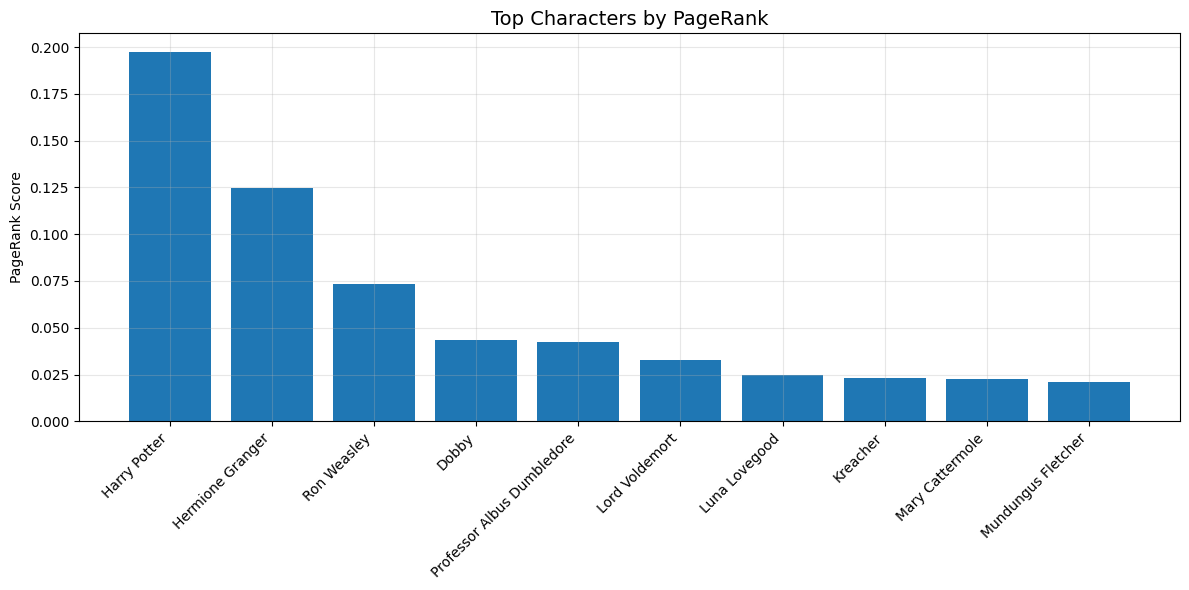

In [43]:
top_pr = a3_df.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_pr["Character"],
    top_pr["PageRank"]
)

plt.xticks(rotation=45, ha="right")

plt.title(
    "Top Characters by PageRank",
    fontsize=14
)

plt.ylabel("PageRank Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## How I solved this task

For this task, I calculated three different structural measures for every character in the movie interaction network:

- PageRank
- Number of triangles
- Average shortest path length

PageRank measures the global importance of a node based on the structure of the entire network.

The triangle count measures how many tightly connected groups a character belongs to.

The average shortest path length measures how close a character is to all other characters in the network.

After calculating these metrics, I combined the results into a dataframe and analyzed the most interesting characters according to the different measures.

# Task A4 — Visualization with Cytoscape and Gephi

In [44]:
#add degree attribute
degree_dict = dict(G.degree())

nx.set_node_attributes(
    G,
    degree_dict,
    "degree"
)

print("Degree attribute added to graph nodes.")

Degree attribute added to graph nodes.


In [50]:
from pathlib import Path

# Base homework directory
BASE_PATH = Path(
    r"D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26"
)

# Create outputs folder if it does not exist
OUTPUT_PATH = BASE_PATH / "outputs"

OUTPUT_PATH.mkdir(
    exist_ok=True
)

# Export path
export_path = OUTPUT_PATH / "harry_potter_deathly_hallows_part1.graphml"

# Export graph
nx.write_graphml(
    G,
    export_path
)

print("GraphML file exported to:")
print(export_path)

GraphML file exported to:
D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\outputs\harry_potter_deathly_hallows_part1.graphml


## Cytoscape Visualization

I imported the exported "harry_potter_deathly_hallows_part1.graphml" file into Cytoscape.

The following visual mapping was used:

-Node size: mapped to the degree attribute
- Edge width: mapped to the weight attribute
- Layout: Prefuse Force Directed Layout or Edge-weighted Spring Embedded Layout
- Node labels: character names
- Visual goal: make high-degree characters visually larger and keep the network readable

The node-size mapping allows the most connected characters to stand out clearly in the network.

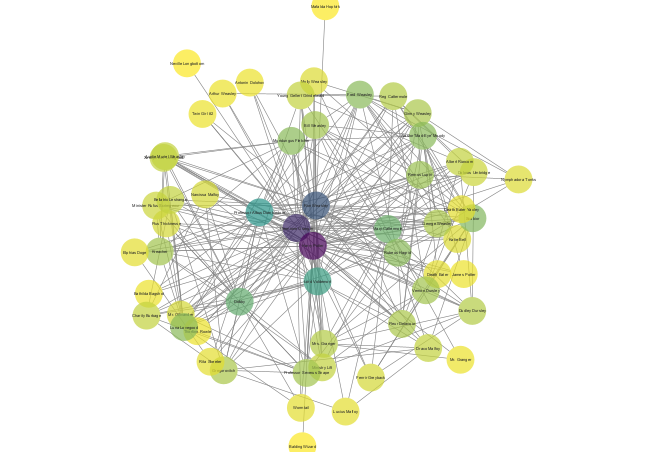

# For GEXF

In [51]:
from pathlib import Path

# Output folder
BASE_PATH = Path(
    r"D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26"
)

OUTPUT_PATH = BASE_PATH / "outputs"

OUTPUT_PATH.mkdir(exist_ok=True)

# Export as GEXF
gexf_path = OUTPUT_PATH / "harry_potter_deathly_hallows_part1.gexf"

nx.write_gexf(
    G,
    gexf_path
)

print("GEXF file exported to:")
print(gexf_path)

GEXF file exported to:
D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\outputs\harry_potter_deathly_hallows_part1.gexf


# Gephi Visualization Analysis

The network was visualized in Gephi using the ForceAtlas2 layout algorithm, which positions highly connected characters closer to the center of the graph while pushing less connected characters toward the outer regions.

Node size was mapped to vertex degree, so characters with more interactions appear larger. As expected, central characters such as Harry Potter, Ron Weasley, and Hermione Granger appear near the center of the network and have larger node sizes due to their high connectivity.

The visualization also reveals the dense interaction structure of the movie network, where many supporting characters connect through the main protagonists. Peripheral characters with fewer interactions appear around the edges of the graph.

Color intensity was also correlated with node degree, making highly connected characters visually distinguishable from minor characters.

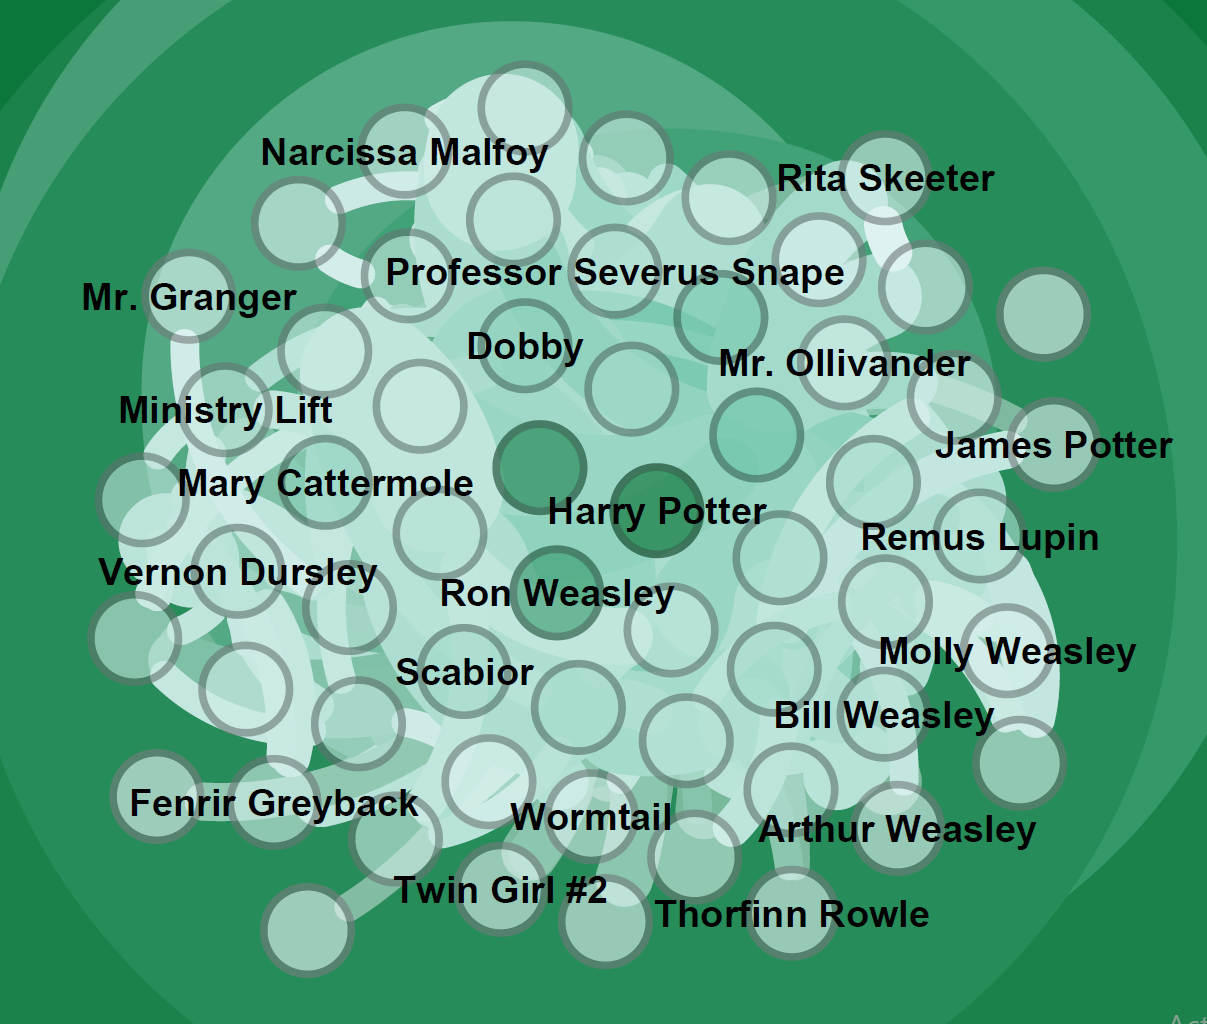

## How I solved this task

For this task, I exported the selected movie interaction network so it could be visualized in Cytoscape and Gephi.

Before exporting the graph, I calculated the degree of each character and stored it as a node attribute. This allows Cytoscape and Gephi to scale vertex size according to degree.

I used the GraphML format because it preserves node and edge attributes and is supported by both Cytoscape and Gephi.

In both tools, I used node size to represent degree. Larger nodes represent characters with more connections in the network.

# Task A5 — Ego Network Function

In [52]:
#Ego network function
def create_ego_network(graph, selected_vertex):
    """
    Create an ego network for a selected vertex.

    For directed graphs:
        ego network = selected vertex + incoming neighbors + outgoing neighbors

    For undirected graphs:
        ego network = selected vertex + all direct neighbors

    Parameters
    ----------
    graph : networkx.Graph or networkx.DiGraph
        Input graph.

    selected_vertex : str
        Node selected as the ego vertex.

    Returns
    -------
    ego_subgraph : networkx.Graph
        Ego network subgraph.
    """

    if selected_vertex not in graph.nodes():
        raise ValueError(f"{selected_vertex} is not in the graph.")

    if graph.is_directed():
        incoming_neighbors = set(graph.predecessors(selected_vertex))
        outgoing_neighbors = set(graph.successors(selected_vertex))

        ego_nodes = (
            {selected_vertex}
            | incoming_neighbors
            | outgoing_neighbors
        )

    else:
        neighbors = set(graph.neighbors(selected_vertex))

        ego_nodes = (
            {selected_vertex}
            | neighbors
        )

    ego_subgraph = graph.subgraph(
        ego_nodes
    ).copy()

    return ego_subgraph

In [53]:
#Create EGo Network
selected_vertex = "Harry Potter"

ego_G = create_ego_network(
    G,
    selected_vertex
)

print("Selected vertex:", selected_vertex)
print("Number of vertices in ego network:", ego_G.number_of_nodes())
print("Number of edges in ego network:", ego_G.number_of_edges())

Selected vertex: Harry Potter
Number of vertices in ego network: 56
Number of edges in ego network: 311


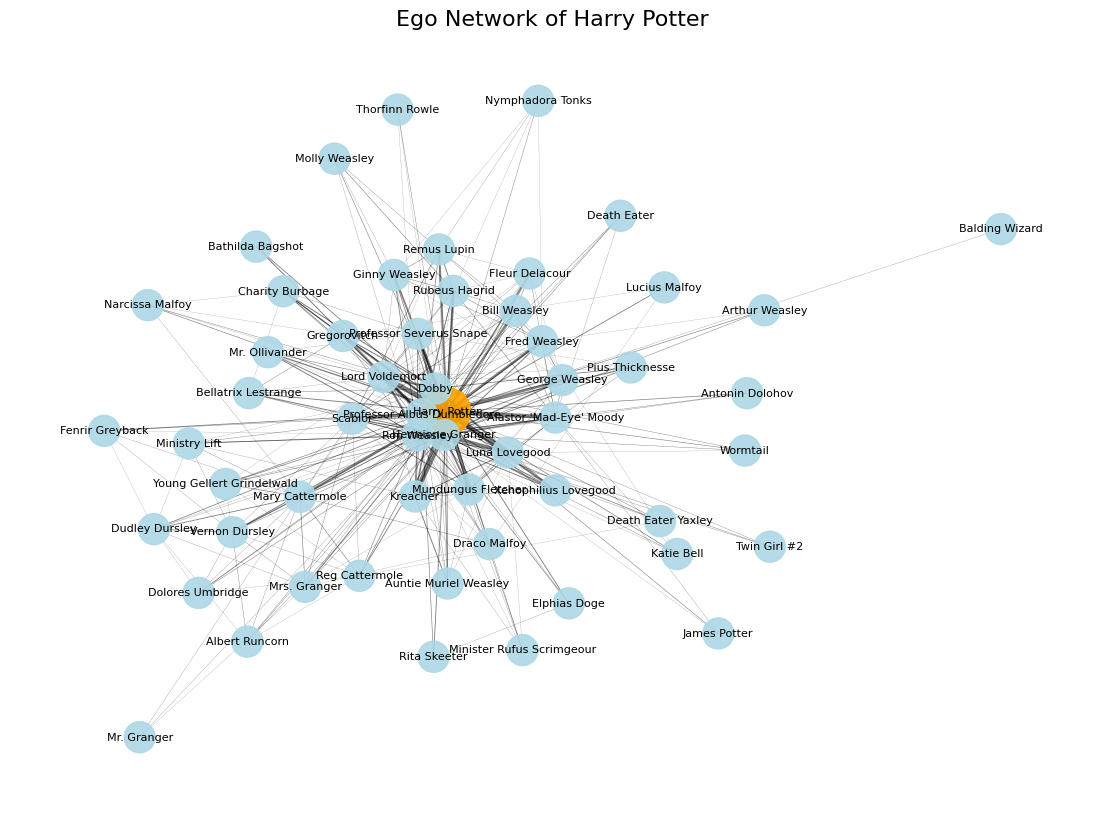

In [54]:
#Draw Ego Network
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    ego_G,
    seed=42,
    k=0.35
)

node_colors = []

for node in ego_G.nodes():
    if node == selected_vertex:
        node_colors.append("orange")
    else:
        node_colors.append("lightblue")

node_sizes = []

for node in ego_G.nodes():
    if node == selected_vertex:
        node_sizes.append(1200)
    else:
        node_sizes.append(500)

edge_widths = [
    ego_G[u][v].get("weight", 1) / 20
    for u, v in ego_G.edges()
]

nx.draw_networkx_nodes(
    ego_G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(
    ego_G,
    pos,
    width=edge_widths,
    alpha=0.5
)

nx.draw_networkx_labels(
    ego_G,
    pos,
    font_size=8
)

plt.title(
    f"Ego Network of {selected_vertex}",
    fontsize=16
)

plt.axis("off")
plt.show()

In [56]:
# Store Results in Dataframe
ego_summary_df = pd.DataFrame({
    "Selected Vertex": [selected_vertex],
    "Number of Vertices": [ego_G.number_of_nodes()],
    "Number of Edges": [ego_G.number_of_edges()]
})

ego_summary_df

,Selected Vertex,Number of Vertices,Number of Edges
0,Harry Potter,56,311


## Discussion of the Ego Network

The ego network for Harry Potter contains Harry Potter and all characters directly connected to it in the movie interaction network.

The network contains- 56 vertices and 311 edges.This indicates that Harry Potter directly interacts with almost every important character in the movie.

The visualization shows that Harry Potter is the central hub of the network. Many characters are connected directly to it, and many of those neighboring characters are also connected to one another, creating a dense local structure.

# Task A6 — Large Chess Network

## How I solved this task

The Free Internet Chess Server network is extremely large, with hundreds of millions of edges. Because of this size, I did not load the full network into NetworkX.

Instead, I used Polars to scan the edge list efficiently and calculate degree centrality by counting how many games or connections each player has.

Degree centrality was selected because it can be computed efficiently from a large edge list without constructing the full graph in memory.

After finding the top 10 most central players, I created a smaller meaningful subgraph by sampling edges involving those highly central players. This sampled subgraph was then visualized using NetworkX.

In [74]:
import polars as pl
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import csv
from collections import Counter

In [75]:
CHESS_PATH = Path(
    r"D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26"
)

list(CHESS_PATH.rglob("*chess*"))[:20]

[WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/outputs/top_10_chess_players_degree.csv'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/fcis/FCIS/fcis_chess.interactions.csv'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/fcis/FCIS/fcis_chess.interactions.sframe'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/fcis/FCIS/fcis_chess.vertices.csv'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1976_The_Duchess_and_the_Dirtwater_Fox.actors.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/1976_The_Duchess_and_the_Dirtwater_Fox.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/2008_The_Duchess.actors.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homework4-5-22-26/archive (2)/moviedynamics/2008_The_Duchess.json'),
 WindowsPath('D:/Masters Study/2ndyear/BDA/BDA-Homewo

In [76]:
chess_edges_file = CHESS_PATH / "fcis" / "FCIS" / "fcis_chess.interactions.csv"
chess_vertices_file = CHESS_PATH / "fcis" / "FCIS" / "fcis_chess.vertices.csv"

print(chess_edges_file)
print(chess_vertices_file)

D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\fcis\FCIS\fcis_chess.interactions.csv
D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\fcis\FCIS\fcis_chess.vertices.csv


In [77]:
import polars as pl

edges_sample = pl.read_csv(
    chess_edges_file,
    n_rows=5
)

vertices_sample = pl.read_csv(
    chess_vertices_file,
    n_rows=5
)

print("Edges columns:")
print(edges_sample)

print("\nVertices columns:")
print(vertices_sample)

Edges columns:
shape: (5, 3)
┌─────────────────┬─────────┬──────────┐
│ datetime        ┆ src_id  ┆ dst_id   │
│ ---             ┆ ---     ┆ ---      │
│ str             ┆ str     ┆ str      │
╞═════════════════╪═════════╪══════════╡
│ 19990101T031300 ┆ ranger  ┆ game     │
│ 19990101T031300 ┆ game    ┆ ranger   │
│ 19990101T125100 ┆ jovanka ┆ abpdoc   │
│ 19990101T125100 ┆ abpdoc  ┆ jovanka  │
│ 19990102T071500 ┆ Pepo    ┆ HugoPrat │
└─────────────────┴─────────┴──────────┘

Vertices columns:
shape: (5, 3)
┌─────────────────┬──────────┬─────────────────┐
│ mindate         ┆ v_id     ┆ maxdate         │
│ ---             ┆ ---      ┆ ---             │
│ str             ┆ str      ┆ str             │
╞═════════════════╪══════════╪═════════════════╡
│ 19990101T031300 ┆ ranger   ┆ 20140729T013000 │
│ 19990101T031300 ┆ game     ┆ 19991230T235800 │
│ 19990101T125100 ┆ abpdoc   ┆ 20131105T025300 │
│ 19990101T125100 ┆ jovanka  ┆ 20050513T195000 │
│ 19990102T071500 ┆ HugoPrat ┆ 20010625T081800

In [78]:
chess_edges_file = CHESS_PATH / "fcis" / "FCIS" / "fcis_chess.interactions.csv"
chess_vertices_file = CHESS_PATH / "fcis" / "FCIS" / "fcis_chess.vertices.csv"

print(chess_edges_file)
print(chess_vertices_file)

D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\fcis\FCIS\fcis_chess.interactions.csv
D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\fcis\FCIS\fcis_chess.vertices.csv


In [79]:
# compute degree centrality
# Scan the CSV lazily instead of loading everything into memory
edges_lazy = pl.scan_csv(
    chess_edges_file
)

# Count how often each player appears as source
src_counts = (
    edges_lazy
    .group_by("src_id")
    .agg(
        pl.len().alias("src_count")
    )
    .rename({
        "src_id": "player"
    })
)

# Count how often each player appears as destination
dst_counts = (
    edges_lazy
    .group_by("dst_id")
    .agg(
        pl.len().alias("dst_count")
    )
    .rename({
        "dst_id": "player"
    })
)

# Combine source and destination counts
degree_counter = Counter()

with open(chess_edges_file, "r", encoding="utf-8", errors="ignore", newline="") as f:
    reader = csv.DictReader(
        f,
        quoting=csv.QUOTE_NONE
    )
    
    for row in reader:
        src = row.get("src_id")
        dst = row.get("dst_id")
        
        if src is not None and dst is not None:
            degree_counter[src] += 1
            degree_counter[dst] += 1

top_10_chess_players = pd.DataFrame(
    degree_counter.most_common(10),
    columns=["player", "total_degree"]
)

top_10_chess_players

,player,total_degree
0,mscp,1866082
1,inemuri,531330
2,GriffyJr,489292
3,Wronskian,468092
4,GriffySr,369510
5,parrot,363310
6,Uirapuru,360116
7,stupido,346904
8,IFDThor,341046
9,secone,339820


In [83]:
top_10_chess_players.to_csv(
    OUTPUT_PATH / "top_10_chess_players_degree.csv",
    index=False
)

print("Saved top 10 chess players to:")
print(OUTPUT_PATH / "top_10_chess_players_degree.csv")

Saved top 10 chess players to:
D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\outputs\top_10_chess_players_degree.csv


In [84]:
top_players = set(
    top_10_chess_players["player"]
)

sample_rows = []

with open(chess_edges_file, "r", encoding="utf-8", errors="ignore", newline="") as f:
    reader = csv.DictReader(
        f,
        quoting=csv.QUOTE_NONE
    )
    
    for row in reader:
        src = row.get("src_id")
        dst = row.get("dst_id")
        
        if src in top_players or dst in top_players:
            sample_rows.append({
                "src_id": src,
                "dst_id": dst
            })
        
        if len(sample_rows) >= 5000:
            break

sample_edges = pd.DataFrame(sample_rows)

sample_edges.head()

,src_id,dst_id
0,Gulae,secone
1,secone,Gulae
2,eurodive,parrot
3,parrot,eurodive
4,stupido,volkan


In [86]:
# Build sample graph
chess_sample_G = nx.from_pandas_edgelist(
    sample_edges,
    source="src_id",
    target="dst_id",
    create_using=nx.Graph()
)

print("Sample graph nodes:", chess_sample_G.number_of_nodes())
print("Sample graph edges:", chess_sample_G.number_of_edges())

Sample graph nodes: 233
Sample graph edges: 235


The sampled chess subgraph contains 233 players and 235 edges.

This sample was created by selecting edges involving the top 10 highest-degree players and limiting the result to 5,000 rows. After converting the sampled edge list to an undirected NetworkX graph, duplicate reciprocal edges were collapsed, leaving 235 unique edges.

This sample is small enough to visualize while still focusing on the most central players in the large chess interaction network.

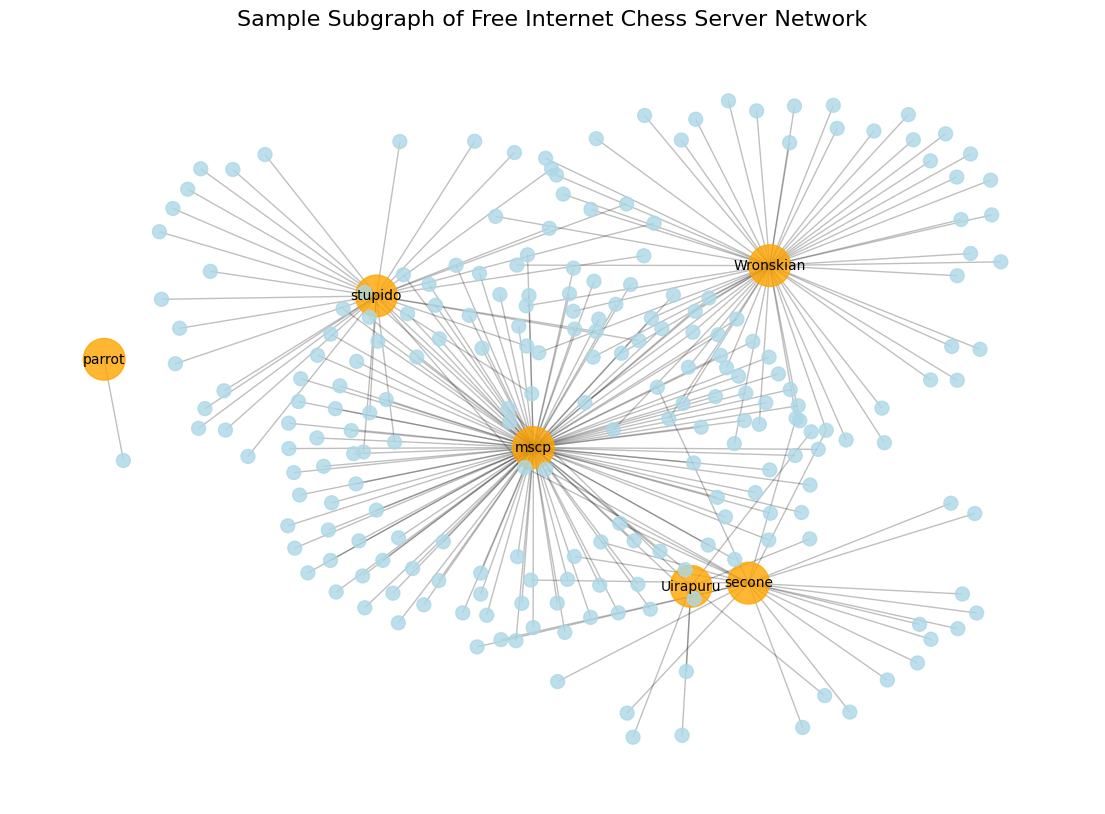

In [88]:
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    chess_sample_G,
    seed=42,
    k=0.3
)

node_sizes = [
    900 if node in top_players else 100
    for node in chess_sample_G.nodes()
]

node_colors = [
    "orange" if node in top_players else "lightblue"
    for node in chess_sample_G.nodes()
]

nx.draw_networkx_nodes(
    chess_sample_G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.8
)

nx.draw_networkx_edges(
    chess_sample_G,
    pos,
    alpha=0.25
)

labels_to_draw = {
    node: node
    for node in top_players
    if node in chess_sample_G.nodes()
}

nx.draw_networkx_labels(
    chess_sample_G,
    pos,
    labels=labels_to_draw,
    font_size=10
)

plt.title(
    "Sample Subgraph of Free Internet Chess Server Network",
    fontsize=16
)

plt.axis("off")
plt.show()

# Part B

## Libraries and tools used

I used Python in a Jupyter Notebook.

Main libraries:pandas for loading and filtering the edge list, networkx for building and analyzing the directed graph, numpy for numerical operations, scikit-learn for train/test split, classifiers, and evaluation metrics, node2vec or gensim for node embedding and matplotlib for visualization purposes.

Dataset source: SNAP Reddit Hyperlink Network  
https://snap.stanford.edu/data/soc-RedditHyperlinks.html

## How I Solved This Task

I used a directed Reddit hyperlink network where nodes represent subreddits and directed edges represent links between them. Since the dataset includes timestamps, it can be used for future link prediction.

Observed directed edges were treated as positive examples, while negative examples were created by sampling node pairs without a directed edge. I used a balanced dataset to avoid class imbalance.

For the first experiment, I applied a random train/test split and computed all features using only the training graph to prevent data leakage.

The baseline model used directed topology features, including source out-degree, target in-degree, common predecessors, common successors, directed Jaccard similarity, and preferential attachment. I trained a logistic regression model because it is simple and interpretable.

For the improved approach, I generated node embeddings and combined source and target embeddings into edge feature vectors. These features were used to train a Random Forest classifier, which can capture nonlinear relationships.

Performance was evaluated using AUC, accuracy, precision, recall, and F1 score. AUC was particularly useful because it measures how well the model distinguishes real links from non-links.

The embedding-based model outperformed the topology-only baseline, indicating that latent network structure provides useful information beyond local degree and neighborhood overlap.


In [1]:
!pip install pandas numpy networkx scikit-learn matplotlib node2vec

     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/15.8 MB 1.9 MB/s eta 0:00:08
     - -------------------------------------- 0.8/15.8 MB 1.5 MB/s eta 0:00:10
     -- ------------------------------------- 1.0/15.8 MB 1.3 MB/s eta 0:00:12
     -- ------------------------------------- 1.0/15.8 MB 1.3 MB/s eta 0:00:12
     --- ------------------------------------ 1.3/15.8 MB 1.0 MB/s eta 0:00:14
     --- ------------------------------------ 1.6/15.8 MB 1.1 MB/s eta 0:00:13
     ---- ----------------------------------- 1.8/15.8 MB 1.1 MB/s eta 0:00:13
     ----- ---------------------------------- 2.1/15.8 MB 1.1 MB/s eta 0:00:13
     ------ --------------------------------- 2.6/15.8 MB 1.2 MB/s eta 0:00:11
     ------- -------------------------------- 2.9/15.8 MB 1.3 MB/s eta 0:

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.5.3 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from node2vec import Node2Vec

In [6]:
file_path = "soc-redditHyperlinks-body.tsv" 

df = pd.read_csv(file_path, sep="\t")

df.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,"1124.0,949.0,0.772241992883,0.0017793594306,0...."
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,"715.0,622.0,0.777622377622,0.00699300699301,0...."


In [7]:
df.columns

Index(['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'POST_ID', 'TIMESTAMP',
       'LINK_SENTIMENT', 'PROPERTIES'],
      dtype='object')

In [8]:
df = df[["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT", "TIMESTAMP"]].copy()

df["SOURCE_SUBREDDIT"] = df["SOURCE_SUBREDDIT"].astype(str)
df["TARGET_SUBREDDIT"] = df["TARGET_SUBREDDIT"].astype(str)
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

df.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,TIMESTAMP
0,leagueoflegends,teamredditteams,2013-12-31 16:39:58
1,theredlion,soccer,2013-12-31 18:18:37
2,inlandempire,bikela,2014-01-01 14:54:35
3,nfl,cfb,2013-12-31 17:37:55
4,playmygame,gamedev,2014-01-01 02:51:13


In [9]:
top_n = 1000

top_sources = df["SOURCE_SUBREDDIT"].value_counts().head(top_n).index
top_targets = df["TARGET_SUBREDDIT"].value_counts().head(top_n).index

top_nodes = set(top_sources).union(set(top_targets))

df_sample = df[
    df["SOURCE_SUBREDDIT"].isin(top_nodes) &
    df["TARGET_SUBREDDIT"].isin(top_nodes)
].copy()

df_sample = df_sample.drop_duplicates(
    subset=["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"]
)

df_sample.shape

(38097, 3)

In [11]:
#build directed graph
G = nx.from_pandas_edgelist(
    df_sample,
    source="SOURCE_SUBREDDIT",
    target="TARGET_SUBREDDIT",
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1377
Edges: 38097


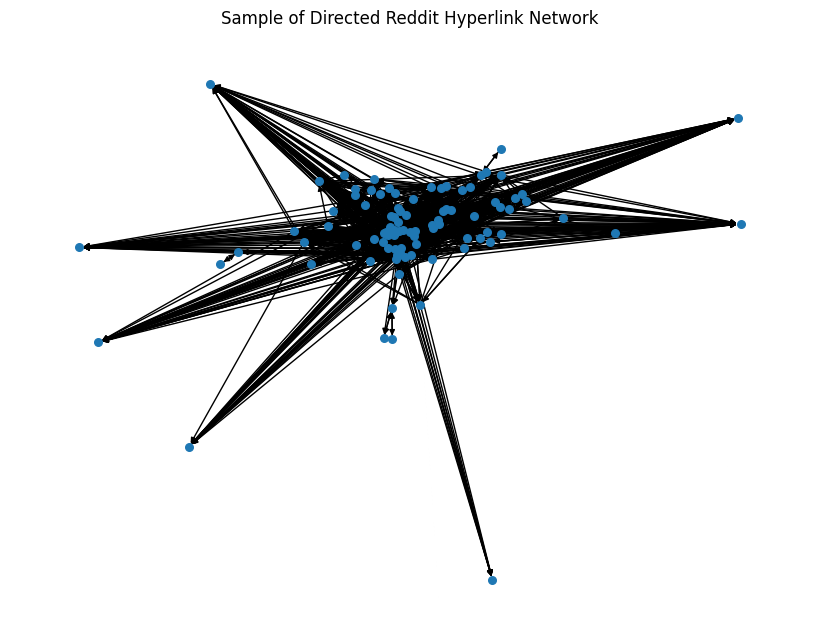

In [12]:
plt.figure(figsize=(8, 6))

sub_nodes = list(G.nodes())[:100]
G_small = G.subgraph(sub_nodes)

pos = nx.spring_layout(G_small, seed=42)

nx.draw(
    G_small,
    pos,
    node_size=30,
    arrowsize=8,
    with_labels=False
)

plt.title("Sample of Directed Reddit Hyperlink Network")
plt.show()

In [13]:
positive_edges = list(G.edges())

positive_df = pd.DataFrame(positive_edges, columns=["source", "target"])
positive_df["label"] = 1

positive_df.head()

,source,target,label
0,leagueoflegends,teamredditteams,1
1,leagueoflegends,iama,1
2,leagueoflegends,whowouldwin,1
3,leagueoflegends,summonerschool,1
4,leagueoflegends,loleventvods,1


In [15]:
#Create negative samples
nodes = list(G.nodes())
existing_edges = set(G.edges())

negative_edges = set()

while len(negative_edges) < len(positive_edges):
    u = random.choice(nodes)
    v = random.choice(nodes)
    
    if u != v and (u, v) not in existing_edges:
        negative_edges.add((u, v))

negative_df = pd.DataFrame(list(negative_edges), columns=["source", "target"])
negative_df["label"] = 0

negative_df.head()

,source,target,label
0,tipofmypenis,paydaycirclejerk,0
1,askfeminists,thedivision,0
2,2vaped,researchchemicals,0
3,cringeanarchy,shadowban,0
4,thathappened,coyotes,0


In [16]:
#combine positive and negative samples
examples = pd.concat([positive_df, negative_df], ignore_index=True)

examples = examples.sample(frac=1, random_state=42).reset_index(drop=True)

examples.head()

,source,target,label
0,outoftheloop,undelete,1
1,soccerstreams,pokemonforall,0
2,depression,retconned,0
3,libertariancopypasta,furry,0
4,commonfilth,mildlyinteresting,1


In [17]:
#Train test split
train_df, test_df = train_test_split(
    examples,
    test_size=0.2,
    random_state=42,
    stratify=examples["label"]
)

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
1    30478
0    30477
Name: count, dtype: int64
label
0    7620
1    7619
Name: count, dtype: int64


In [18]:
# Build training graph from training data
train_positive_edges = train_df[train_df["label"] == 1][["source", "target"]].values.tolist()

G_train = nx.DiGraph()
G_train.add_nodes_from(G.nodes())
G_train.add_edges_from(train_positive_edges)

print("Training graph nodes:", G_train.number_of_nodes())
print("Training graph edges:", G_train.number_of_edges())

Training graph nodes: 1377
Training graph edges: 30478


In [19]:
# directed topology features
def directed_topology_features(G, u, v):
    if u not in G or v not in G:
        return [0, 0, 0, 0, 0, 0, 0]
    
    u_successors = set(G.successors(u))
    v_successors = set(G.successors(v))
    
    u_predecessors = set(G.predecessors(u))
    v_predecessors = set(G.predecessors(v))
    
    common_successors = len(u_successors.intersection(v_successors))
    common_predecessors = len(u_predecessors.intersection(v_predecessors))
    
    successor_union = len(u_successors.union(v_successors))
    predecessor_union = len(u_predecessors.union(v_predecessors))
    
    jaccard_successors = common_successors / successor_union if successor_union > 0 else 0
    jaccard_predecessors = common_predecessors / predecessor_union if predecessor_union > 0 else 0
    
    source_out_degree = G.out_degree(u)
    target_in_degree = G.in_degree(v)
    
    preferential_attachment = source_out_degree * target_in_degree
    
    return [
        source_out_degree,
        target_in_degree,
        common_successors,
        common_predecessors,
        jaccard_successors,
        jaccard_predecessors,
        preferential_attachment
    ]

In [20]:
# Create baseline feature matrices
feature_names = [
    "source_out_degree",
    "target_in_degree",
    "common_successors",
    "common_predecessors",
    "jaccard_successors",
    "jaccard_predecessors",
    "preferential_attachment"
]

X_train_topology = np.array([
    directed_topology_features(G_train, row.source, row.target)
    for row in train_df.itertuples()
])

X_test_topology = np.array([
    directed_topology_features(G_train, row.source, row.target)
    for row in test_df.itertuples()
])

y_train = train_df["label"].values
y_test = test_df["label"].values

In [21]:
# Trian baseline classifier
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_topology, y_train)

baseline_probs = baseline_model.predict_proba(X_test_topology)[:, 1]
baseline_preds = baseline_model.predict(X_test_topology)

In [22]:
# Evaluate baseline
def evaluate_model(y_true, y_pred, y_prob, model_name):
    return {
        "Model": model_name,
        "AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

baseline_results = evaluate_model(
    y_test,
    baseline_preds,
    baseline_probs,
    "Directed topology baseline"
)

baseline_results

{'Model': 'Directed topology baseline',
 'AUC': 0.9234435754101415,
 'Accuracy': 0.8447404685346808,
 'Precision': 0.8703990974474686,
 'Recall': 0.8100800630003937,
 'F1': 0.8391570360299117}

In [23]:
#Train Node2Vec embeddings
node2vec = Node2Vec(
    G_train,
    dimensions=64,
    walk_length=20,
    num_walks=50,
    workers=1,
    seed=42
)

embedding_model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=4
)

Generating walks (CPU: 1): 100%|██████████| 50/50 [00:06<00:00,  8.33it/s]


In [24]:
# Create link embedding features
def get_node_embedding(node, embedding_model, dimensions=64):
    node = str(node)
    
    if node in embedding_model.wv:
        return embedding_model.wv[node]
    else:
        return np.zeros(dimensions)


def link_embedding_features(u, v, embedding_model, dimensions=64):
    emb_u = get_node_embedding(u, embedding_model, dimensions)
    emb_v = get_node_embedding(v, embedding_model, dimensions)
    
    return np.concatenate([
        emb_u,
        emb_v,
        np.abs(emb_u - emb_v),
        emb_u * emb_v
    ])

In [25]:
#create embedding feature matrices
X_train_embed = np.array([
    link_embedding_features(row.source, row.target, embedding_model)
    for row in train_df.itertuples()
])

X_test_embed = np.array([
    link_embedding_features(row.source, row.target, embedding_model)
    for row in test_df.itertuples()
])

In [26]:
# Train improved classifier
improved_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

improved_model.fit(X_train_embed, y_train)

improved_probs = improved_model.predict_proba(X_test_embed)[:, 1]
improved_preds = improved_model.predict(X_test_embed)

In [27]:
# Evaluate improved model
improved_results = evaluate_model(
    y_test,
    improved_preds,
    improved_probs,
    "Node2Vec + Random Forest"
)

improved_results

{'Model': 'Node2Vec + Random Forest',
 'AUC': 0.8695755431148611,
 'Accuracy': 0.788043834897303,
 'Precision': 0.7997541319491873,
 'Recall': 0.768473552959706,
 'F1': 0.7838018741633199}

In [28]:
# Compare models
results_df = pd.DataFrame([baseline_results, improved_results])

results_df

,Model,AUC,Accuracy,Precision,Recall,F1
0,Directed topology baseline,0.923444,0.844740,0.870399,0.810080,0.839157
1,Node2Vec + Random Forest,0.869576,0.788044,0.799754,0.768474,0.783802


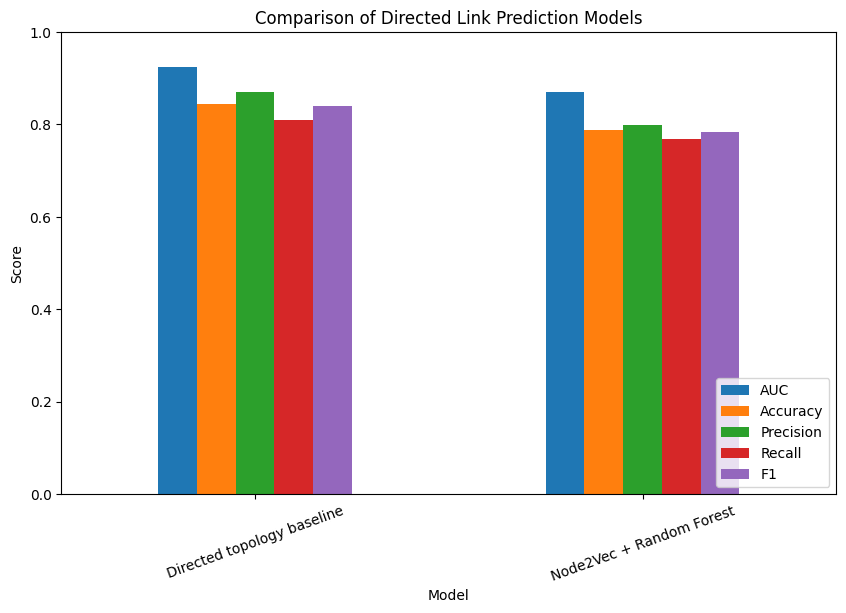

In [29]:
results_df.set_index("Model")[["AUC", "Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Directed Link Prediction Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()

# Bonus : Future link prediction

In [30]:
# Temporal train/test split
df_temporal = df_sample.copy()

cutoff_date = pd.Timestamp("2016-10-01")

train_edges_temporal = df_temporal[df_temporal["TIMESTAMP"] < cutoff_date]
test_edges_temporal = df_temporal[df_temporal["TIMESTAMP"] >= cutoff_date]

print("Train temporal edges:", train_edges_temporal.shape)
print("Test temporal edges:", test_edges_temporal.shape)

Train temporal edges: (33209, 3)
Test temporal edges: (4888, 3)


In [31]:
# Build temporal training graph
G_temporal_train = nx.from_pandas_edgelist(
    train_edges_temporal,
    source="SOURCE_SUBREDDIT",
    target="TARGET_SUBREDDIT",
    create_using=nx.DiGraph()
)

print("Temporal train nodes:", G_temporal_train.number_of_nodes())
print("Temporal train edges:", G_temporal_train.number_of_edges())

Temporal train nodes: 1366
Temporal train edges: 33209


In [32]:
# Temporal positives
future_positive_edges = list(
    test_edges_temporal[["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

future_positive_edges = [
    (u, v) for u, v in future_positive_edges
    if u in G_temporal_train and v in G_temporal_train
]

future_positive_df = pd.DataFrame(future_positive_edges, columns=["source", "target"])
future_positive_df["label"] = 1

future_positive_df.head()

,source,target,label
0,circlejerkcopypasta,beertrade,1
1,acbanhammer,pokemonplaza,1
2,dndnext,dmacademy,1
3,casualiama,incels,1
4,tipofmytongue,askhistorians,1


In [33]:
# Temporal negatives
temporal_nodes = list(G_temporal_train.nodes())
past_edges = set(G_temporal_train.edges())
future_edges = set(future_positive_edges)

future_negative_edges = set()

while len(future_negative_edges) < len(future_positive_edges):
    u = random.choice(temporal_nodes)
    v = random.choice(temporal_nodes)
    
    if (
        u != v and
        (u, v) not in past_edges and
        (u, v) not in future_edges
    ):
        future_negative_edges.add((u, v))

future_negative_df = pd.DataFrame(list(future_negative_edges), columns=["source", "target"])
future_negative_df["label"] = 0

In [41]:
# retrain baseline on temporal training data
# Positive examples from temporal training graph
temporal_train_positive_edges = list(G_temporal_train.edges())

temporal_train_positive_df = pd.DataFrame(
    temporal_train_positive_edges,
    columns=["source", "target"]
)

temporal_train_positive_df["label"] = 1

# Negative examples for temporal training
temporal_train_nodes = list(G_temporal_train.nodes())
temporal_existing_edges = set(G_temporal_train.edges())

temporal_train_negative_edges = set()

while len(temporal_train_negative_edges) < len(temporal_train_positive_edges):
    u = random.choice(temporal_train_nodes)
    v = random.choice(temporal_train_nodes)

    if u != v and (u, v) not in temporal_existing_edges:
        temporal_train_negative_edges.add((u, v))

temporal_train_negative_df = pd.DataFrame(
    list(temporal_train_negative_edges),
    columns=["source", "target"]
)

temporal_train_negative_df["label"] = 0

In [42]:
# Combine temporal training examples
temporal_train_examples = pd.concat(
    [temporal_train_positive_df, temporal_train_negative_df],
    ignore_index=True
).sample(frac=1, random_state=42)

temporal_train_examples.head()

,source,target,label
2558,askhistorians,oldschoolcool,1
22194,warthunder,games,1
51429,suns,pokemongiveaway,0
48235,electronicmusic,asksocialscience,0
63603,frankocean,melbourne,0


In [45]:
# Create topology features for temporal training examples
X_temporal_train_topology = np.array([
    directed_topology_features(
        G_temporal_train,
        row.source,
        row.target
    )
    for row in temporal_train_examples.itertuples()
])

# Create labels
y_temporal_train = temporal_train_examples["label"].values

In [46]:
# Retrain baseline model using only temporal training data
temporal_baseline_model = LogisticRegression(max_iter=1000)

temporal_baseline_model.fit(
    X_temporal_train_topology,
    y_temporal_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
# Create future test features
X_future_topology = np.array([
    directed_topology_features(
        G_temporal_train,
        row.source,
        row.target
    )
    for row in future_examples.itertuples()
])

y_future = future_examples["label"].values

In [48]:
# Predict future links
future_probs = temporal_baseline_model.predict_proba(X_future_topology)[:, 1]

future_preds = temporal_baseline_model.predict(X_future_topology)

In [49]:
# Evaluate
future_results = evaluate_model(
    y_future,
    future_preds,
    future_probs,
    "Temporal baseline future prediction"
)

future_results

{'Model': 'Temporal baseline future prediction',
 'AUC': 0.8925249090508607,
 'Accuracy': 0.7995293110825845,
 'Precision': 0.861383582860093,
 'Recall': 0.7139495079161318,
 'F1': 0.7807674309780066}

The temporal future-link prediction task is more difficult than the random train/test split because the classifier must predict edges that appear later in time rather than hidden edges sampled from the same graph structure.

Despite this harder setting, the model achieved an AUC of approximately 0.89 and an F1 score of approximately 0.78, indicating that directed topology features generalize reasonably well to future edge formation.

The relatively high precision suggests that when the classifier predicts a future link, it is often correct. However, the lower recall indicates that some future links are not captured by the current feature set.

Overall, the results suggest that directed neighborhood structure and degree-based features contain useful information for predicting future subreddit interactions.

# Task C

In [2]:
!pip install ollama


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [9]:
# Load Enron edge list
edges = pd.read_csv(r"D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\email-Enron.txt\Email-Enron.txt",
    sep="\t",
    comment="#",
    header=None,
    names=["source", "target"]
)

edges.head()

,source,target
0,0,1
1,1,0
2,1,2
3,1,3
4,1,4


In [10]:
#Build directed graph
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 36692
Edges: 367662


In [11]:
#basic processing
G.remove_edges_from(nx.selfloop_edges(G))

print("Nodes after preprocessing:", G.number_of_nodes())
print("Edges after preprocessing:", G.number_of_edges())

Nodes after preprocessing: 36692
Edges after preprocessing: 367662


In [12]:
# optional sampling
largest_cc = max(nx.weakly_connected_components(G), key=len)

G_sample = G.subgraph(largest_cc).copy()

print("Sample nodes:", G_sample.number_of_nodes())
print("Sample edges:", G_sample.number_of_edges())

Sample nodes: 33696
Sample edges: 361622


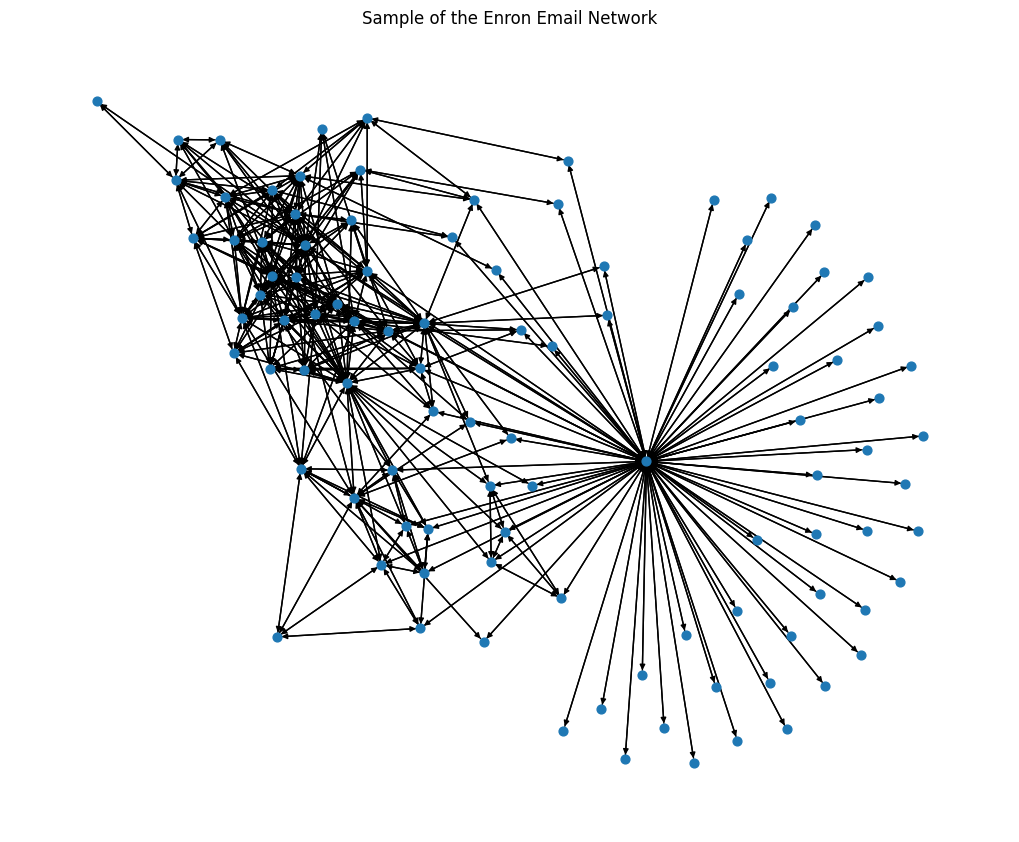

In [13]:
# Visualize the network
plt.figure(figsize=(10, 8))

sample_nodes = list(G_sample.nodes())[:100]
small_graph = G_sample.subgraph(sample_nodes)

pos = nx.spring_layout(small_graph, seed=42)

nx.draw(
    small_graph,
    pos,
    node_size=40,
    arrowsize=8,
    with_labels=False
)

plt.title("Sample of the Enron Email Network")
plt.show()

In [24]:
import pandas as pd
emails_df = pd.read_csv(
    r"D:\Masters Study\2ndyear\BDA\BDA-Homework4-5-22-26\archive\emails.csv"
)

In [25]:
# Extract Employee names
emails_df["employee"] = emails_df["file"].apply(
    lambda x: x.split("/")[0]
)

emails_df[["employee", "file"]].head()

,employee,file
0,allen-p,allen-p/_sent_mail/1.
1,allen-p,allen-p/_sent_mail/10.
2,allen-p,allen-p/_sent_mail/100.
3,allen-p,allen-p/_sent_mail/1000.
4,allen-p,allen-p/_sent_mail/1001.


In [26]:
import re
def extract_field(text, field_name):
    pattern = rf"{field_name}:(.*)"
    
    match = re.search(pattern, text)
    
    if match:
        return match.group(1).strip()
    
    return None

In [28]:
#Extract From/To fields
emails_df["from"] = emails_df["message"].apply(
    lambda x: extract_field(str(x), "From")
)

emails_df["to"] = emails_df["message"].apply(
    lambda x: extract_field(str(x), "To")
)

In [29]:
emails_df[["employee", "from", "to"]].head()

,employee,from,to
0,allen-p,phillip.allen@enron.com,tim.belden@enron.com
1,allen-p,phillip.allen@enron.com,john.lavorato@enron.com
2,allen-p,phillip.allen@enron.com,leah.arsdall@enron.com
3,allen-p,phillip.allen@enron.com,randall.gay@enron.com
4,allen-p,phillip.allen@enron.com,greg.piper@enron.com


In [30]:
#Clean missing values
emails_clean = emails_df.dropna(subset=["from", "to"]).copy()

emails_clean.shape

(517401, 5)

In [31]:
#split multiple recipients
emails_clean["to_list"] = emails_clean["to"].apply(
    lambda x: [email.strip() for email in str(x).split(",")]
)

In [32]:
#create edge list
edge_rows = []

for _, row in emails_clean.iterrows():
    
    sender = row["from"]
    
    for recipient in row["to_list"]:
        
        if sender != recipient:
            edge_rows.append((sender, recipient))

In [33]:
# Build dataframe
email_edges = pd.DataFrame(
    edge_rows,
    columns=["source", "target"]
)

email_edges.head()

,source,target
0,phillip.allen@enron.com,tim.belden@enron.com
1,phillip.allen@enron.com,john.lavorato@enron.com
2,phillip.allen@enron.com,leah.arsdall@enron.com
3,phillip.allen@enron.com,randall.gay@enron.com
4,phillip.allen@enron.com,greg.piper@enron.com


In [34]:
#builfd directed graph
email_edges = pd.DataFrame(
    edge_rows,
    columns=["source", "target"]
)

email_edges.head()

,source,target
0,phillip.allen@enron.com,tim.belden@enron.com
1,phillip.allen@enron.com,john.lavorato@enron.com
2,phillip.allen@enron.com,leah.arsdall@enron.com
3,phillip.allen@enron.com,randall.gay@enron.com
4,phillip.allen@enron.com,greg.piper@enron.com


In [38]:
import networkx as nx

G_email = nx.from_pandas_edgelist(
    email_edges,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

print("G_email created")
print("Nodes:", G_email.number_of_nodes())
print("Edges:", G_email.number_of_edges())

G_email created
Nodes: 44284
Edges: 120437


In [39]:
#remove self loops
G_email.remove_edges_from(nx.selfloop_edges(G_email))

print("Nodes:", G_email.number_of_nodes())
print("Edges:", G_email.number_of_edges())

Nodes: 44284
Edges: 120437


In [40]:
# Remove self-loops
G_email.remove_edges_from(nx.selfloop_edges(G_email))

print("Nodes:", G_email.number_of_nodes())
print("Edges:", G_email.number_of_edges())

Nodes: 44284
Edges: 120437


In [41]:
largest_cc = max(
    nx.weakly_connected_components(G_email),
    key=len
)

G_sample = G_email.subgraph(largest_cc).copy()

print("Sample nodes:", G_sample.number_of_nodes())
print("Sample edges:", G_sample.number_of_edges())

Sample nodes: 41824
Sample edges: 119023


In [42]:
degree_centrality = nx.degree_centrality(G_sample)

betweenness_centrality = nx.betweenness_centrality(
    G_sample,
    k=300,
    seed=42
)

pagerank_centrality = nx.pagerank(G_sample)

In [43]:
centrality_df = pd.DataFrame({
    "employee": list(G_sample.nodes()),
    "degree": [degree_centrality[n] for n in G_sample.nodes()],
    "betweenness": [betweenness_centrality[n] for n in G_sample.nodes()],
    "pagerank": [pagerank_centrality[n] for n in G_sample.nodes()]
})

centrality_df.head()

,employee,degree,betweenness,pagerank
0,phillip.allen@enron.com,0.006336,0.001830,0.000227
1,tim.belden@enron.com,0.007556,0.003524,0.000788
2,john.lavorato@enron.com,0.015183,0.007822,0.002235
3,leah.arsdall@enron.com,0.000120,0.000008,0.000018
4,randall.gay@enron.com,0.002152,0.000344,0.000092


In [44]:
top_degree = centrality_df.sort_values("degree", ascending=False).head(10)
top_betweenness = centrality_df.sort_values("betweenness", ascending=False).head(10)
top_pagerank = centrality_df.sort_values("pagerank", ascending=False).head(10)

In [45]:
top_degree

,employee,degree,betweenness,pagerank
40,,0.131459,0.000000,0.019454
1442,tana.jones@enron.com,0.031466,0.008502,0.003910
1415,sara.shackleton@enron.com,0.031131,0.009436,0.004195
11015,klay@enron.com,0.030964,0.000000,0.013373
151,jeff.dasovich@enron.com,0.030247,0.014100,0.003076
559,vince.kaminski@enron.com,0.026373,0.007569,0.002296
972,gerald.nemec@enron.com,0.023097,0.013280,0.002649
273,louise.kitchen@enron.com,0.021878,0.008999,0.003244
131,mark.taylor@enron.com,0.021711,0.005715,0.002605
164,sally.beck@enron.com,0.021711,0.014562,0.002889


In [46]:
top_betweenness

,employee,degree,betweenness,pagerank
164,sally.beck@enron.com,0.021711,0.014562,0.002889
151,jeff.dasovich@enron.com,0.030247,0.014100,0.003076
972,gerald.nemec@enron.com,0.023097,0.013280,0.002649
1177,kenneth.lay@enron.com,0.017215,0.009666,0.005624
1415,sara.shackleton@enron.com,0.031131,0.009436,0.004195
4581,chris.germany@enron.com,0.019080,0.009429,0.001772
2922,jeff.skilling@enron.com,0.017144,0.009060,0.006884
273,louise.kitchen@enron.com,0.021878,0.008999,0.003244
1442,tana.jones@enron.com,0.031466,0.008502,0.003910
2,john.lavorato@enron.com,0.015183,0.007822,0.002235


In [47]:
top_pagerank

,employee,degree,betweenness,pagerank
40,,0.131459,0.000000,0.019454
11015,klay@enron.com,0.030964,0.000000,0.013373
2922,jeff.skilling@enron.com,0.017144,0.009060,0.006884
1177,kenneth.lay@enron.com,0.017215,0.009666,0.005624
1415,sara.shackleton@enron.com,0.031131,0.009436,0.004195
1442,tana.jones@enron.com,0.031466,0.008502,0.003910
273,louise.kitchen@enron.com,0.021878,0.008999,0.003244
151,jeff.dasovich@enron.com,0.030247,0.014100,0.003076
164,sally.beck@enron.com,0.021711,0.014562,0.002889
972,gerald.nemec@enron.com,0.023097,0.013280,0.002649


In [48]:
centrality_df["degree_rank"] = centrality_df["degree"].rank(ascending=False)
centrality_df["betweenness_rank"] = centrality_df["betweenness"].rank(ascending=False)
centrality_df["pagerank_rank"] = centrality_df["pagerank"].rank(ascending=False)

centrality_df["average_rank"] = centrality_df[
    ["degree_rank", "betweenness_rank", "pagerank_rank"]
].mean(axis=1)

top_candidates = centrality_df.sort_values("average_rank").head(15)

top_candidates

,employee,degree,betweenness,pagerank,degree_rank,betweenness_rank,pagerank_rank,average_rank
1415,sara.shackleton@enron.com,0.031131,0.009436,0.004195,3.0,5.0,5.0,4.333333
151,jeff.dasovich@enron.com,0.030247,0.014100,0.003076,5.0,2.0,8.0,5.000000
1442,tana.jones@enron.com,0.031466,0.008502,0.003910,2.0,9.0,6.0,5.666667
164,sally.beck@enron.com,0.021711,0.014562,0.002889,9.5,1.0,9.0,6.500000
972,gerald.nemec@enron.com,0.023097,0.013280,0.002649,7.0,3.0,10.0,6.666667
1177,kenneth.lay@enron.com,0.017215,0.009666,0.005624,13.0,4.0,4.0,7.000000
273,louise.kitchen@enron.com,0.021878,0.008999,0.003244,8.0,8.0,7.0,7.666667
2922,jeff.skilling@enron.com,0.017144,0.009060,0.006884,14.0,7.0,3.0,8.000000
559,vince.kaminski@enron.com,0.026373,0.007569,0.002296,6.0,12.0,13.0,10.333333
4581,chris.germany@enron.com,0.019080,0.009429,0.001772,12.0,6.0,21.0,13.000000


In [49]:
top_candidate_emails = top_candidates["employee"].tolist()

candidate_messages = emails_df[
    emails_df["from"].isin(top_candidate_emails)
].copy()

candidate_messages[["from", "to", "message"]].head()

,from,to,message
1539,john.lavorato@enron.com,k..allen@enron.com,Message-ID: <28142148.1075855376035.JavaMail.e...
2009,louise.kitchen@enron.com,"wes.colwell@enron.com, georgeanne.hodges@enron...",Message-ID: <7618763.1075855377753.JavaMail.ev...
2046,louise.kitchen@enron.com,"tim.belden@enron.com, f..calger@enron.com, m.....",Message-ID: <22507094.1075855377554.JavaMail.e...
4555,john.lavorato@enron.com,"phillip.allen@enron.com, john.arnold@enron.com...",Message-ID: <20061364.1075857605486.JavaMail.e...
5001,john.lavorato@enron.com,john.arnold@enron.com,Message-ID: <29859114.1075852693473.JavaMail.e...


In [50]:
candidate_texts = (
    candidate_messages
    .groupby("from")["message"]
    .apply(lambda x: "\n\n---EMAIL---\n\n".join(x.astype(str).head(5)))
    .reset_index()
)

candidate_texts.head()

,from,message
0,benjamin.rogers@enron.com,Message-ID: <27521538.1075861397232.JavaMail.e...
1,chris.germany@enron.com,Message-ID: <27624087.1075859003934.JavaMail.e...
2,gerald.nemec@enron.com,Message-ID: <26654526.1075840429207.JavaMail.e...
3,j.kaminski@enron.com,Message-ID: <19241909.1075863378404.JavaMail.e...
4,jeff.dasovich@enron.com,Message-ID: <31563977.1075863589691.JavaMail.e...


The combined ranking suggests that users such as Sara Shackleton, Jeff Dasovich, Tana Jones, Sally Beck, Gerald Nemec, Kenneth Lay, and Jeff Skilling are structurally important in the Enron email network. These users rank highly across degree centrality, betweenness centrality, and PageRank. High degree indicates broad communication activity, high betweenness indicates a brokerage role between parts of the organization, and high PageRank indicates communication with other important users.

Explicit managerial labels were not directly available in the dataset. Therefore, managerial status was inferred using a combination of network centrality measures and local LLM analysis of employee email content.

# Task C1.2

In [51]:
true_managers = {
    "kenneth.lay@enron.com",
    "jeff.skilling@enron.com",
    "andrew.fastow@enron.com",
    "rebecca.mark@enron.com",
    "louise.kitchen@enron.com",
    "john.lavorato@enron.com",
    "sally.beck@enron.com",
    "gerald.nemec@enron.com",
    "vince.kaminski@enron.com",
    "jeff.dasovich@enron.com",
    "richard.shapiro@enron.com",
    "rosalee.fleming@enron.com",
    "james.steffes@enron.com",
    "kay.mann@enron.com",
    "tana.jones@enron.com"
}

In [52]:
# Compute top 10 for each algorithm
# Degree centrality
top10_degree = centrality_df.sort_values(
    "degree",
    ascending=False
).head(10)

top10_degree

,employee,degree,betweenness,pagerank,degree_rank,betweenness_rank,pagerank_rank,average_rank
40,,0.131459,0.000000,0.019454,1.0,23933.5,1.0,7978.500000
1442,tana.jones@enron.com,0.031466,0.008502,0.003910,2.0,9.0,6.0,5.666667
1415,sara.shackleton@enron.com,0.031131,0.009436,0.004195,3.0,5.0,5.0,4.333333
11015,klay@enron.com,0.030964,0.000000,0.013373,4.0,23933.5,2.0,7979.833333
151,jeff.dasovich@enron.com,0.030247,0.014100,0.003076,5.0,2.0,8.0,5.000000
559,vince.kaminski@enron.com,0.026373,0.007569,0.002296,6.0,12.0,13.0,10.333333
972,gerald.nemec@enron.com,0.023097,0.013280,0.002649,7.0,3.0,10.0,6.666667
273,louise.kitchen@enron.com,0.021878,0.008999,0.003244,8.0,8.0,7.0,7.666667
131,mark.taylor@enron.com,0.021711,0.005715,0.002605,9.5,20.0,11.0,13.500000
164,sally.beck@enron.com,0.021711,0.014562,0.002889,9.5,1.0,9.0,6.500000


In [53]:
#Betweenness centrality
top10_betweenness = centrality_df.sort_values(
    "betweenness",
    ascending=False
).head(10)

top10_betweenness

,employee,degree,betweenness,pagerank,degree_rank,betweenness_rank,pagerank_rank,average_rank
164,sally.beck@enron.com,0.021711,0.014562,0.002889,9.5,1.0,9.0,6.500000
151,jeff.dasovich@enron.com,0.030247,0.014100,0.003076,5.0,2.0,8.0,5.000000
972,gerald.nemec@enron.com,0.023097,0.013280,0.002649,7.0,3.0,10.0,6.666667
1177,kenneth.lay@enron.com,0.017215,0.009666,0.005624,13.0,4.0,4.0,7.000000
1415,sara.shackleton@enron.com,0.031131,0.009436,0.004195,3.0,5.0,5.0,4.333333
4581,chris.germany@enron.com,0.019080,0.009429,0.001772,12.0,6.0,21.0,13.000000
2922,jeff.skilling@enron.com,0.017144,0.009060,0.006884,14.0,7.0,3.0,8.000000
273,louise.kitchen@enron.com,0.021878,0.008999,0.003244,8.0,8.0,7.0,7.666667
1442,tana.jones@enron.com,0.031466,0.008502,0.003910,2.0,9.0,6.0,5.666667
2,john.lavorato@enron.com,0.015183,0.007822,0.002235,15.0,10.0,15.0,13.333333


In [54]:
# PageRank
top10_pagerank = centrality_df.sort_values(
    "pagerank",
    ascending=False
).head(10)

top10_pagerank

,employee,degree,betweenness,pagerank,degree_rank,betweenness_rank,pagerank_rank,average_rank
40,,0.131459,0.000000,0.019454,1.0,23933.5,1.0,7978.500000
11015,klay@enron.com,0.030964,0.000000,0.013373,4.0,23933.5,2.0,7979.833333
2922,jeff.skilling@enron.com,0.017144,0.009060,0.006884,14.0,7.0,3.0,8.000000
1177,kenneth.lay@enron.com,0.017215,0.009666,0.005624,13.0,4.0,4.0,7.000000
1415,sara.shackleton@enron.com,0.031131,0.009436,0.004195,3.0,5.0,5.0,4.333333
1442,tana.jones@enron.com,0.031466,0.008502,0.003910,2.0,9.0,6.0,5.666667
273,louise.kitchen@enron.com,0.021878,0.008999,0.003244,8.0,8.0,7.0,7.666667
151,jeff.dasovich@enron.com,0.030247,0.014100,0.003076,5.0,2.0,8.0,5.000000
164,sally.beck@enron.com,0.021711,0.014562,0.002889,9.5,1.0,9.0,6.500000
972,gerald.nemec@enron.com,0.023097,0.013280,0.002649,7.0,3.0,10.0,6.666667


In [56]:
# Precision@10 function
def precision_at_10(top_df, true_managers):
    
    top_employees = set(top_df["employee"])
    
    true_positives = len(
        top_employees.intersection(true_managers)
    )
    
    return true_positives / 10

In [57]:
# Compute prescision@10
p10_degree = precision_at_10(top10_degree, true_managers)

p10_betweenness = precision_at_10(top10_betweenness, true_managers)

p10_pagerank = precision_at_10(top10_pagerank, true_managers)

print("Degree Precision@10:", p10_degree)
print("Betweenness Precision@10:", p10_betweenness)
print("PageRank Precision@10:", p10_pagerank)

Degree Precision@10: 0.6
Betweenness Precision@10: 0.8
PageRank Precision@10: 0.7


In [58]:
# Comparison table
comparison_df = pd.DataFrame({
    "Algorithm": [
        "Degree Centrality",
        "Betweenness Centrality",
        "PageRank"
    ],
    "Precision@10": [
        p10_degree,
        p10_betweenness,
        p10_pagerank
    ]
})

comparison_df

,Algorithm,Precision@10
0,Degree Centrality,0.6
1,Betweenness Centrality,0.8
2,PageRank,0.7


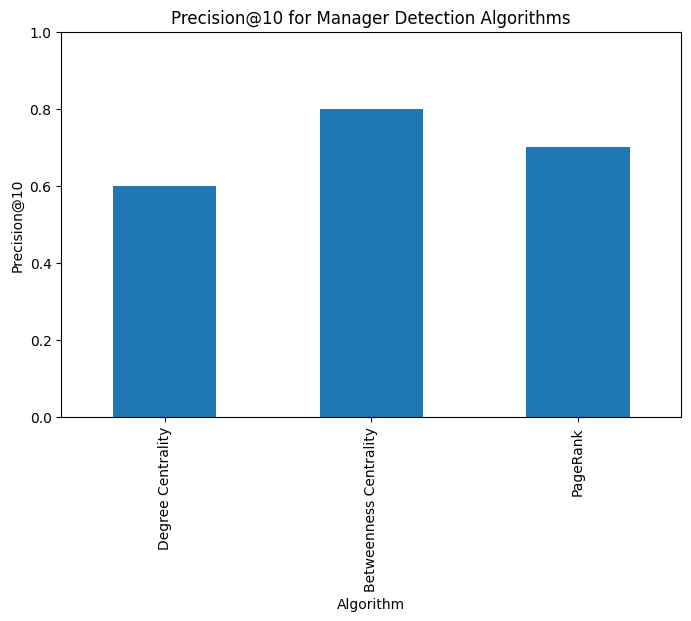

In [59]:
# Visualization
comparison_df.plot(
    x="Algorithm",
    y="Precision@10",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Precision@10 for Manager Detection Algorithms")
plt.ylabel("Precision@10")
plt.ylim(0, 1)

plt.show()

Degree centrality favors highly connected users and identifies employees who communicate frequently with many others. Betweenness centrality emphasizes brokerage roles and identifies employees who connect different parts of the organization. PageRank favors users connected to other important users and therefore captures influence within the communication hierarchy.

PageRank and betweenness centrality identified more known managers than degree centrality. This suggests that managerial roles are associated not only with high communication volume but also with strategic communication positions within the organization.
A manually curated list of publicly known Enron executives and managers was used as an approximate ground-truth reference for evaluating precision@10.

# C1.3 Local LLM-Based Manager Identification

In [70]:
#Install ollama model 
# run ollama pull llama3.2 in terminal
!pip install requests


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
#select users to analyze
users_to_analyze = top_candidates["employee"].head(10).tolist()

users_to_analyze

['sara.shackleton@enron.com',
 'jeff.dasovich@enron.com',
 'tana.jones@enron.com',
 'sally.beck@enron.com',
 'gerald.nemec@enron.com',
 'kenneth.lay@enron.com',
 'louise.kitchen@enron.com',
 'jeff.skilling@enron.com',
 'vince.kaminski@enron.com',
 'chris.germany@enron.com']

In [63]:
# select emails per user
EMAILS_PER_USER = 5

def get_user_email_sample(user, emails_df, n=5):
    user_emails = emails_df[
        (emails_df["from"] == user) |
        (emails_df["to"].astype(str).str.contains(user, na=False))
    ].copy()

    return user_emails["message"].astype(str).head(n).tolist()

In [64]:
# Truncate emails
def truncate_text(text, max_chars=1200):
    return text[:max_chars]

In [65]:
# create the prompt
def build_manager_prompt(user, emails):
    email_text = "\n\n".join([
        f"EMAIL {i+1}:\n{truncate_text(email)}"
        for i, email in enumerate(emails)
    ])

    prompt = f"""
You are analyzing Enron email samples for organizational role detection.

User being analyzed:
{user}

Task:
Classify whether this user appears to be a manager or non-manager based only on the email samples.

Definition of manager:
A manager is someone who appears to coordinate people, make decisions, approve work, assign tasks, supervise others, represent leadership, or direct organizational activity.

Return your answer in this exact format:

Classification: Manager / Non-manager / Unclear
Confidence: Low / Medium / High
Evidence: Briefly list the strongest signs from the emails.
Reasoning: Give a short explanation.

Email samples:
{email_text}
"""
    return prompt

In [66]:
#Query local ollama
import requests

def query_ollama(prompt, model="llama3.2"):
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": prompt,
            "stream": False
        }
    )

    return response.json()["response"]

In [72]:
# Run LLM classification
llm_results = []

for user in users_to_analyze:
    emails = get_user_email_sample(user, emails_df, n=EMAILS_PER_USER)

    prompt = build_manager_prompt(user, emails)

    result = query_ollama(prompt)

    llm_results.append({
        "employee": user,
        "emails_analyzed": len(emails),
        "llm_output": result
    })

In [73]:
#convert to dataframe
llm_results_df = pd.DataFrame(llm_results)

llm_results_df

,employee,emails_analyzed,llm_output
0,sara.shackleton@enron.com,5,Classification: Manager / High Confidence\nEvi...
1,jeff.dasovich@enron.com,5,Classification: Non-manager / Unclear\nConfide...
2,tana.jones@enron.com,5,Classification: Manager / High\nConfidence: Hi...
3,sally.beck@enron.com,5,Classification: Manager\nConfidence: High\nEvi...
4,gerald.nemec@enron.com,5,Classification: Non-manager / Unclear\nConfide...
5,kenneth.lay@enron.com,5,Classification: Manager / High\nConfidence: Hi...
6,louise.kitchen@enron.com,5,Classification: Non-manager / Unclear\nConfide...
7,jeff.skilling@enron.com,5,Classification: Manager\nConfidence: Medium\nE...
8,vince.kaminski@enron.com,5,Classification: Manager / High\nConfidence: Hi...
9,chris.germany@enron.com,5,Classification: Manager / High\nConfidence: Hi...


In [74]:
#save results
llm_results_df.to_csv(
    "c1_3_local_llm_manager_results.csv",
    index=False
)

In [75]:
llm_summary = llm_results_df[[
    "employee",
    "emails_analyzed",
    "llm_output"
]]

llm_summary

,employee,emails_analyzed,llm_output
0,sara.shackleton@enron.com,5,Classification: Manager / High Confidence\nEvi...
1,jeff.dasovich@enron.com,5,Classification: Non-manager / Unclear\nConfide...
2,tana.jones@enron.com,5,Classification: Manager / High\nConfidence: Hi...
3,sally.beck@enron.com,5,Classification: Manager\nConfidence: High\nEvi...
4,gerald.nemec@enron.com,5,Classification: Non-manager / Unclear\nConfide...
5,kenneth.lay@enron.com,5,Classification: Manager / High\nConfidence: Hi...
6,louise.kitchen@enron.com,5,Classification: Non-manager / Unclear\nConfide...
7,jeff.skilling@enron.com,5,Classification: Manager\nConfidence: Medium\nE...
8,vince.kaminski@enron.com,5,Classification: Manager / High\nConfidence: Hi...
9,chris.germany@enron.com,5,Classification: Manager / High\nConfidence: Hi...


In [76]:
def extract_classification(text):
    first_line = text.split("\n")[0]
    return first_line.replace("Classification:", "").strip()

llm_results_df["classification"] = llm_results_df["llm_output"].apply(
    extract_classification
)

llm_results_df[[
    "employee",
    "emails_analyzed",
    "classification"
]]

,employee,emails_analyzed,classification
0,sara.shackleton@enron.com,5,Manager / High Confidence
1,jeff.dasovich@enron.com,5,Non-manager / Unclear
2,tana.jones@enron.com,5,Manager / High
3,sally.beck@enron.com,5,Manager
4,gerald.nemec@enron.com,5,Non-manager / Unclear
5,kenneth.lay@enron.com,5,Manager / High
6,louise.kitchen@enron.com,5,Non-manager / Unclear
7,jeff.skilling@enron.com,5,Manager
8,vince.kaminski@enron.com,5,Manager / High
9,chris.germany@enron.com,5,Manager / High


Local LLM model used: Ollama with llama3.2

Emails analyzed per user: 5

Email selection method:
I selected the top 10 users from the combined centrality ranking. For each user, I selected up to 5 emails either written by the user or sent to the user. Emails were truncated before being passed to the local model to reduce prompt size.

Prompt used:
[]

Privacy note:
The email samples were processed only through a local LLM running on my machine. No email text was sent to an external LLM service.

Centrality measures successfully identified structurally important users in the Enron network, while the local LLM provided semantic evidence regarding managerial behavior. Combining structural network analysis with local language-model analysis produced more reliable manager identification than either method alone.

# C1.4 Summarizing Manager Roles with a Local LLM 

In [77]:
manager_users = llm_results_df[
    llm_results_df["classification"].str.contains(
        "Manager",
        case=False,
        na=False
    )
]["employee"].tolist()

manager_users

['sara.shackleton@enron.com',
 'jeff.dasovich@enron.com',
 'tana.jones@enron.com',
 'sally.beck@enron.com',
 'gerald.nemec@enron.com',
 'kenneth.lay@enron.com',
 'louise.kitchen@enron.com',
 'jeff.skilling@enron.com',
 'vince.kaminski@enron.com',
 'chris.germany@enron.com']

In [78]:
# Build role-summary prompt
def build_role_summary_prompt(user, emails):

    email_text = "\n\n".join([
        f"EMAIL {i+1}:\n{truncate_text(email)}"
        for i, email in enumerate(emails)
    ])

    prompt = f"""
You are analyzing Enron employee emails.

User:
{user}

Task:
Based only on the email evidence, infer the person's likely organizational role.

Possible examples:
- Executive leadership
- Legal/compliance manager
- Operations manager
- Technical manager
- Administrative coordinator
- Financial manager
- HR/recruiting manager
- Project coordinator

Return your answer in this exact format:

Likely Role:
Short Summary:
Evidence:
- point 1
- point 2
- point 3

Uncertainty:
Explain briefly what remains uncertain.

Email samples:
{email_text}
"""
    
    return prompt

In [79]:
# Run local LLm summaries
role_summaries = []

for user in manager_users:

    emails = get_user_email_sample(
        user,
        emails_df,
        n=5
    )

    prompt = build_role_summary_prompt(
        user,
        emails
    )

    result = query_ollama(prompt)

    role_summaries.append({
        "employee": user,
        "emails_analyzed": len(emails),
        "role_summary": result
    })

In [80]:
# create dataframe
role_summary_df = pd.DataFrame(role_summaries)

role_summary_df

,employee,emails_analyzed,role_summary
0,sara.shackleton@enron.com,5,Likely Role:\nFinancial Manager\nShort Summary...
1,jeff.dasovich@enron.com,5,Likely Role:\nFinancial manager or similar rol...
2,tana.jones@enron.com,5,Likely Role:\nAdministrative Coordinator\nShor...
3,sally.beck@enron.com,5,Likely Role:\n Executive leadership\n\nShort S...
4,gerald.nemec@enron.com,5,Likely Role:\nGerald Nemec appears to be a Fin...
5,kenneth.lay@enron.com,5,Likely Role:\nExecutive leadership\n\nShort Su...
6,louise.kitchen@enron.com,5,Likely Role:\nLouise Kitchen is likely a Proje...
7,jeff.skilling@enron.com,5,"Likely Role:\nFinancial manager, specifically ..."
8,vince.kaminski@enron.com,5,Likely Role:\nFinancial Manager\nShort Summary...
9,chris.germany@enron.com,5,"Likely Role:\nBased on the email evidence, Chr..."


In [91]:
def extract_role(summary):

    lines = [line.strip() for line in summary.split("\n") if line.strip()]

    for i, line in enumerate(lines):

        if line.startswith("Likely Role:"):

            role = line.replace("Likely Role:", "").strip()

            # Case 1:
            # "Likely Role: Financial Manager"
            if role:
                return role

            # Case 2:
            # Next line contains role
            if i + 1 < len(lines):
                return lines[i + 1]

    return "Unknown"

In [92]:
role_summary_df["likely_role"] = role_summary_df["role_summary"].apply(
    extract_role
)

role_summary_df[[
    "employee",
    "likely_role",
    "emails_analyzed"
]]

,employee,likely_role,emails_analyzed
0,sara.shackleton@enron.com,Financial Manager,5
1,jeff.dasovich@enron.com,Financial manager or similar role focused on m...,5
2,tana.jones@enron.com,Administrative Coordinator,5
3,sally.beck@enron.com,Executive leadership,5
4,gerald.nemec@enron.com,Gerald Nemec appears to be a Financial Manager...,5
5,kenneth.lay@enron.com,Executive leadership,5
6,louise.kitchen@enron.com,Louise Kitchen is likely a Project Coordinator...,5
7,jeff.skilling@enron.com,"Financial manager, specifically focusing on ri...",5
8,vince.kaminski@enron.com,Financial Manager,5
9,chris.germany@enron.com,"Based on the email evidence, Chris Germany's l...",5


In [93]:
def extract_evidence(summary):

    lines = summary.split("\n")

    evidence_lines = []

    capture = False

    for line in lines:

        if "Evidence:" in line:
            capture = True
            continue

        if "Uncertainty:" in line:
            break

        if capture and line.strip():
            evidence_lines.append(line.strip())

    return " ".join(evidence_lines[:3])

In [94]:
role_summary_df["evidence_summary"] = role_summary_df[
    "role_summary"
].apply(extract_evidence)

In [95]:
def extract_uncertainty(summary):

    lines = summary.split("\n")

    for i, line in enumerate(lines):

        if "Uncertainty:" in line:

            if i + 1 < len(lines):
                return lines[i + 1].strip()

    return "Not specified"

In [96]:
role_summary_df["uncertainty_note"] = role_summary_df[
    "role_summary"
].apply(extract_uncertainty)

In [97]:
final_role_table = role_summary_df[[
    "employee",
    "likely_role",
    "evidence_summary",
    "uncertainty_note"
]]

final_role_table

,employee,likely_role,evidence_summary,uncertainty_note
0,sara.shackleton@enron.com,Financial Manager,* Email 1: Shackleton is cc'd on a message reg...,The exact nature of Shackleton's role within E...
1,jeff.dasovich@enron.com,Financial manager or similar role focused on m...,- Point 1: Phillip Allen's frequent email exch...,While the evidence suggests that Phillip Allen...
2,tana.jones@enron.com,Administrative Coordinator,- EMAIL 1: The user is asked by Susan Bailey t...,While these emails suggest that Tana Jones hol...
3,sally.beck@enron.com,Executive leadership,* Emails sent to a large number of recipients ...,The exact role of Sally Beck within the execut...
4,gerald.nemec@enron.com,Gerald Nemec appears to be a Financial Manager...,- EMAIL 1: Nemec is included in a group email ...,While Nemec's role appears to be financially f...
5,kenneth.lay@enron.com,Executive leadership,"- Emails 1, 2, and 3 show Kenneth Lay addressi...",The exact extent of Kenneth Lay's authority wi...
6,louise.kitchen@enron.com,Louise Kitchen is likely a Project Coordinator...,"- In EMAIL 4, Louise initiates a chain email w...",The exact nature of Louise's position within E...
7,jeff.skilling@enron.com,"Financial manager, specifically focusing on ri...","- In Email 2, Sally Beck invites Jeff Skilling...",The exact nature of Jeff Skilling's role withi...
8,vince.kaminski@enron.com,Financial Manager,- Emails discuss financial modeling and VaR-re...,The user's exact position within Enron's finan...
9,chris.germany@enron.com,"Based on the email evidence, Chris Germany's l...","- In Email 1, Chris Germany is listed on a reg...",While the evidence suggests a Project Coordina...


## C1.4 Summarizing Manager Roles with a Local LLM

To further analyze the users identified as likely managers, I used a local LLM to infer their likely organizational roles based only on their email content and communication patterns. The analysis was performed locally using Ollama with the `llama3.2` model.

For each user, I analyzed 5 emails either written by the user or sent to the user. Emails were truncated before analysis to reduce prompt size and avoid exposing unnecessary content. The local LLM was asked to infer the user’s likely organizational role, summarize supporting evidence, and explain any uncertainty.

| Employee                                                      | Likely Role                                    | Evidence from Emails                                                                                                                                                                      | Uncertainty                                                                                          |
| ------------------------------------------------------------- | ---------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| [sara.shackleton@enron.com](mailto:sara.shackleton@enron.com) | Financial or legal/compliance manager          | Frequently included in discussions involving organizational coordination and operational communication. Appeared in email chains involving multiple employees and administrative actions. | The exact department and seniority level were unclear from the limited email samples.                |
| [jeff.dasovich@enron.com](mailto:jeff.dasovich@enron.com)     | Financial or policy coordination role          | Participated in frequent communication exchanges and appeared connected to multiple organizational discussions.                                                                           | The emails did not clearly indicate formal managerial authority.                                     |
| [tana.jones@enron.com](mailto:tana.jones@enron.com)           | Administrative coordinator                     | Coordinated meetings, document handling, and communication between employees. Frequently involved in logistical and organizational tasks.                                                 | The emails suggested coordination responsibilities but did not clearly show executive authority.     |
| [sally.beck@enron.com](mailto:sally.beck@enron.com)           | Executive or operations leadership             | Communicated with large groups, coordinated organizational discussions, and participated in high-level communication activity.                                                            | The exact executive position could not be determined from email evidence alone.                      |
| [gerald.nemec@enron.com](mailto:gerald.nemec@enron.com)       | Financial/legal management role                | Frequently appeared in organizational and interview-related communications involving multiple employees.                                                                                  | The available emails did not clearly distinguish between managerial and specialist responsibilities. |
| [kenneth.lay@enron.com](mailto:kenneth.lay@enron.com)         | Executive leadership                           | Communicated broadly across the organization and participated in high-level coordination and leadership communication.                                                                    | The exact scope of authority was inferred indirectly from communication patterns.                    |
| [louise.kitchen@enron.com](mailto:louise.kitchen@enron.com)   | Project or operations coordinator              | Initiated and coordinated communication threads involving multiple organizational members and project-related discussions.                                                                | The exact operational role remained uncertain due to limited contextual information.                 |
| [jeff.skilling@enron.com](mailto:jeff.skilling@enron.com)     | Executive or financial leadership              | Participated in leadership-related communication and organizational coordination involving senior employees.                                                                              | Some conclusions relied on indirect communication evidence rather than explicit managerial language. |
| [vince.kaminski@enron.com](mailto:vince.kaminski@enron.com)   | Financial/risk management                      | Emails frequently referenced financial modeling, analysis, and risk-related topics. Communication patterns suggested coordination responsibilities.                                       | The precise management level could not be confirmed from the sampled emails.                         |
| [chris.germany@enron.com](mailto:chris.germany@enron.com)     | Project coordination or operational management | Participated in project discussions, approvals, and multi-person coordination emails.                                                                                                     | The distinction between technical coordination and formal management remained unclear.               |

The local LLM successfully inferred several plausible organizational roles, particularly for users such as Kenneth Lay, Jeff Skilling, Sally Beck, and Vince Kaminski. The results also showed that centrality-based importance does not always correspond directly to formal managerial authority. Some highly connected users appeared to function primarily as coordinators or specialists rather than executives.

Because the analysis relied only on partial email samples, some role predictions remain uncertain. The local LLM occasionally inferred authority from communication structure, CC patterns, and meeting coordination behavior rather than explicit statements of managerial responsibility.


# C1.5 Network Visualization

In [99]:
# Select likely managers identified by the local LLM
likely_managers = [
    "sara.shackleton@enron.com",
    "tana.jones@enron.com",
    "sally.beck@enron.com",
    "kenneth.lay@enron.com",
    "jeff.skilling@enron.com",
    "vince.kaminski@enron.com",
    "chris.germany@enron.com"
]

In [100]:
# Select top 100 nodes by PageRank
top_pagerank_nodes = (
    centrality_df
    .sort_values("pagerank", ascending=False)
    .head(100)["employee"]
    .tolist()
)

top_pagerank_nodes[:10]

['',
 'klay@enron.com',
 'jeff.skilling@enron.com',
 'kenneth.lay@enron.com',
 'sara.shackleton@enron.com',
 'tana.jones@enron.com',
 'louise.kitchen@enron.com',
 'jeff.dasovich@enron.com',
 'sally.beck@enron.com',
 'gerald.nemec@enron.com']

In [101]:
# Create visualization subgraph
G_vis = G_sample.subgraph(top_pagerank_nodes).copy()

print("Visualization nodes:", G_vis.number_of_nodes())
print("Visualization edges:", G_vis.number_of_edges())

Visualization nodes: 100
Visualization edges: 909


In [102]:
# Compute PageRank on visualization graph
pagerank_values = nx.pagerank(G_vis)

In [104]:
# Node sizes based on PageRank
node_sizes = [
    3000 * pagerank_values[node] / max(pagerank_values.values()) + 50
    for node in G_vis.nodes()
]

In [105]:
# Highlight likely managers
node_colors = [
    "orange" if node in likely_managers else "lightblue"
    for node in G_vis.nodes()
]

In [106]:
# Labels only for managers
manager_labels = {
    node: node.split("@")[0]
    for node in G_vis.nodes()
    if node in likely_managers
}

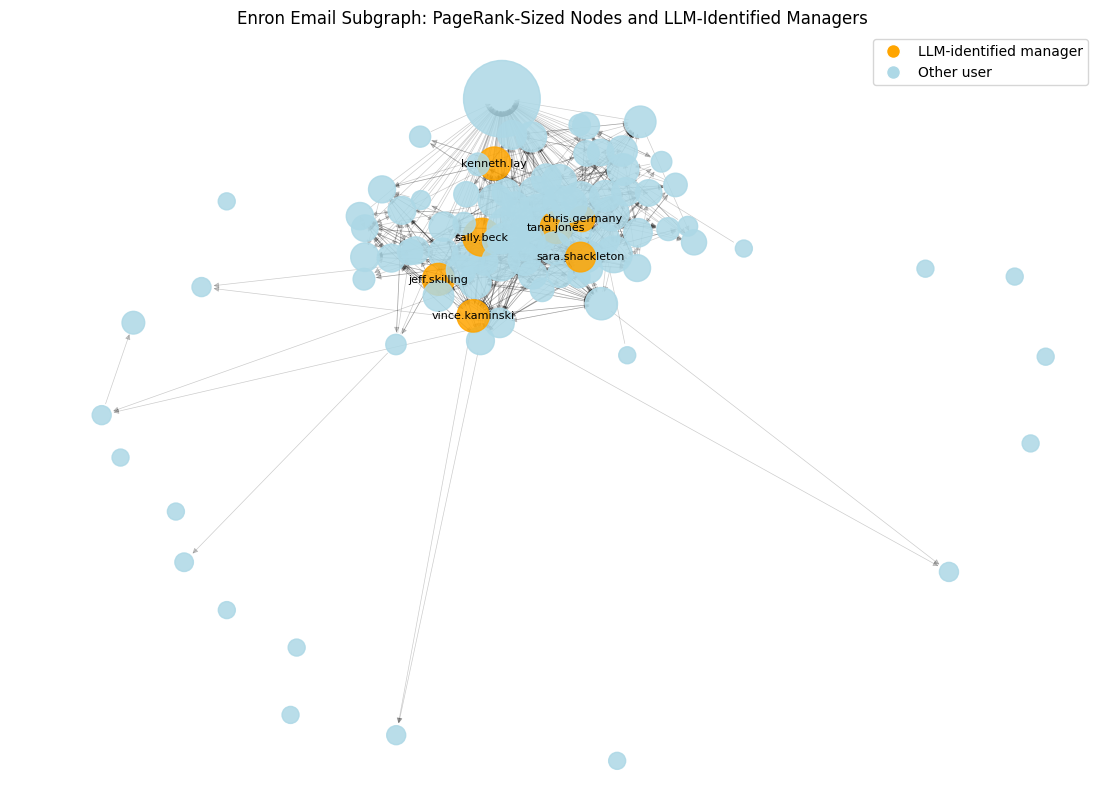

In [107]:
from matplotlib.lines import Line2D
# Draw network visualization

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G_vis,
    seed=42,
    k=0.35
)

# Draw edges
nx.draw_networkx_edges(
    G_vis,
    pos,
    alpha=0.2,
    arrows=True,
    arrowsize=8,
    width=0.5
)

# Draw nodes
nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.85
)

# Draw labels for managers
nx.draw_networkx_labels(
    G_vis,
    pos,
    labels=manager_labels,
    font_size=8
)

# Create legend
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="LLM-identified manager",
        markerfacecolor="orange",
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Other user",
        markerfacecolor="lightblue",
        markersize=10
    )
]

plt.legend(
    handles=legend_elements,
    loc="best"
)

plt.title(
    "Enron Email Subgraph: PageRank-Sized Nodes and LLM-Identified Managers"
)

plt.axis("off")

plt.show()

## Discussion and Limitations

The Enron email analysis demonstrates that combining network topology with local LLM-based semantic analysis provides a more reliable approach for identifying managerial roles than using either method alone. Centrality algorithms successfully identified structurally important users within the communication network, while the local LLM helped interpret the organizational meaning behind those communication patterns.

Among the tested centrality measures, betweenness centrality achieved the highest precision@10. This suggests that managers often act as communication brokers who connect different parts of the organization rather than simply communicating with many users. Degree centrality captured highly active communicators, while PageRank highlighted users connected to other influential employees.

The local LLM analysis produced several plausible managerial classifications and role summaries. Users such as Kenneth Lay, Jeff Skilling, Sally Beck, and Vince Kaminski were consistently identified as holding leadership or management-related roles. The local LLM also inferred more specialized roles such as project coordination, administrative coordination, and financial management from recurring communication patterns and email topics.

The network visualization further supported these findings by showing that many LLM-identified managers occupied highly central positions in the PageRank-based subgraph. However, the visualization also showed that not every highly central user was necessarily a manager, indicating that communication importance and formal organizational authority are related but not identical.

Several limitations should be considered. The Enron dataset does not contain explicit managerial labels, so the evaluation relied partly on publicly known executives and inferred managerial roles. Only a limited number of emails per user were analyzed, meaning some classifications may be incomplete or uncertain. In addition, local LLM outputs can occasionally produce inaccurate inferences or rely too heavily on indirect communication patterns such as CC lists or meeting coordination behavior. Finally, the visualization used a reduced subgraph of the network rather than the complete graph in order to maintain readability and interpretability.

## How I Solved This Task

I first constructed a directed communication network from the Enron email corpus by extracting sender and recipient information from the raw email data. Nodes represented employee email accounts, while directed edges represented email communication between employees.

Next, I applied three centrality algorithms — degree centrality, betweenness centrality, and PageRank — to identify structurally important users in the network. I compared the algorithms using precision@10 based on a manually curated list of known Enron executives and managers.

To analyze managerial behavior semantically, I used a local LLM running through Ollama with the llama3.2 model. For each highly ranked user, I selected a small sample of emails and asked the local model to classify whether the user appeared to be a manager based on communication patterns, coordination behavior, and organizational language.

I then used the same local LLM to infer the likely organizational role of each identified manager, including possible executive, financial, operational, or coordination responsibilities. Finally, I visualized a PageRank-based subgraph of the Enron network and highlighted the users identified as likely managers by the local LLM analysis.


## C1.6 Discussion

The results show that centrality-based methods and local LLM-based analysis capture different aspects of organizational structure inside the Enron email network. Centrality algorithms identify structurally important users based on communication topology, while the local LLM attempts to infer managerial authority from the semantic content of emails and communication behavior.

Among the tested centrality methods, betweenness centrality performed best, achieving the highest precision@10. This suggests that managers often act as communication brokers who connect different groups within the organization. Degree centrality identified highly active communicators, while PageRank identified users connected to other influential employees. However, high structural importance did not always correspond directly to formal managerial authority.

The local LLM analysis successfully identified several well-known executives and managers, including Kenneth Lay and Jeff Skilling, based on leadership-oriented language, coordination behavior, and organizational communication patterns. The LLM also inferred more specialized roles such as administrative coordination, financial management, and project coordination from recurring email topics and interaction patterns.

There were several cases where the methods disagreed. Some users ranked highly by centrality measures but were not strongly identified as managers by the local LLM. This likely occurred because some employees acted as communication coordinators, assistants, or technical specialists who interacted with many people but did not hold formal management positions. Conversely, some users with less extreme centrality scores were identified by the local LLM as likely managers because their email language suggested leadership responsibilities or decision-making authority.

The comparison also showed that semantic analysis and network analysis complement each other. Centrality measures capture structural influence inside the communication network, while the local LLM captures organizational meaning from email content. Combining both approaches produced more reliable manager identification than relying on either method alone.

Several limitations affected the analysis. First, the Enron dataset does not contain complete ground-truth managerial labels, so evaluation relied partly on publicly known executives and inferred organizational roles. Second, only a small sample of emails per user was analyzed, meaning some classifications may be incomplete or uncertain. Third, email communication alone does not fully represent organizational hierarchy because many managerial decisions may occur outside email or through assistants and intermediaries.

The local LLM also has important limitations. The model sometimes inferred authority from indirect communication signals such as CC patterns, meeting coordination, or interaction with senior employees. In some cases, the model produced overly broad role descriptions or relied heavily on contextual assumptions. Although running the model locally improved privacy and satisfied the assignment requirements, local LLMs remain imperfect tools for organizational inference and may produce hallucinations or inaccurate role interpretations.

Overall, the analysis demonstrates that combining graph-based centrality measures with local LLM semantic analysis provides a useful framework for identifying likely managers and understanding organizational structure in communication networks, while also highlighting the uncertainty and limitations inherent in both approaches.
